In [2]:
import sys, pathlib

_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    build_dict_model_params,
    filter_stations_by_nan_fraction,
    load_all_station_rr,
    prepare_station_fit_table,
)
from spatial_bmcd.switch_phi_duration_diagnostic import (
    compute_cells_from_raw,
    equal_duration_estimates,
    figure_targets,
    plot_phi_per_cell_season_grid,
)

SEASONS = list(config.SEASONS)
COUNTRIES = ["PT", "ES"]
YEAR_MIN, YEAR_MAX = 1980, 2020
D_MAX = 20      # equal durations d = d' = 1 ... D_MAX
MIN_DAYS = 10   # admissibility rule of the article

OUTPUT_DIR = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Single-site fitted spell distributions.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)
stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

def build_params_by_season(stations_used):
    """Per-season {city: model parameters} of the PT/ES subset of `stations_used`."""
    out = {}
    for season in SEASONS:
        df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
            df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=season,
        )
        out[season] = build_dict_model_params(
            df_fit_dry_sub, df_fit_wet_sub, spells, season=season, show_progress=False,
        )
    return out

# Station set, settled in two passes: how incomplete a station is can only be
# read from the raw record, so a provisional set says which files to load,
# filter_stations_by_nan_fraction drops the stations missing more than
# MAX_NAN_FRACTION_STATION of the window (see spatial_bmcd/config_spatial.py),
# and the second pass is the definitive set. Only the load touches the disk.
params_by_season = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in params_by_season.values())))
dfs_by_city = load_all_station_rr(
    config.ECAD_RAW_DIR, stations_to_get=stations_union, verbose=False,
)
stations_used = filter_stations_by_nan_fraction(stations_used, dfs_by_city)
params_by_season = build_params_by_season(stations_used)

print("stations per season: " + ", ".join(
    f"{s}={len(params_by_season[s])}" for s in SEASONS))


def equal_duration_metric_table(day_record, cell_metrics, d_max: int = D_MAX) -> pd.DataFrame:
    """One row per (station pair, r, r', d = d' <= d_max): day count + metrics."""
    R, D, B = day_record["R"], day_record["D"], day_record["B"]
    names, dist = day_record["station_names"], day_record["dist"]
    valid = np.isfinite(R) & np.isfinite(D) & np.isfinite(B)
    rows = []
    for j in range(len(names) - 1):
        for k in range(j + 1, len(names)):
            ok = valid[:, j] & valid[:, k]           # both stations on days n, n+1
            d = D[ok, j].astype(int)
            same = (D[ok, k].astype(int) == d) & (d >= 1) & (d <= d_max)
            r_j, r_k = R[ok, j].astype(int)[same], R[ok, k].astype(int)[same]
            b_j, b_k = B[ok, j].astype(int)[same], B[ok, k].astype(int)[same]
            d = d[same]
            for r, rp, dd in np.unique(np.stack([r_j, r_k, d], axis=1), axis=0):
                sel = (r_j == r) & (r_k == rp) & (d == dd)
                rows.append({
                    "station_j": names[j], "station_k": names[k],
                    "dist": float(dist[j, k]),
                    "state_class": ("dry-dry" if r == rp == 0 else
                                    "wet-wet" if r == rp == 1 else "dry-wet"),
                    "r_j": int(r), "r_k": int(rp), "d": int(dd),
                    "n_days": int(sel.sum()),
                    **cell_metrics(b_j[sel], b_k[sel]),
                })
    return pd.DataFrame(rows)


import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from spatial_bmcd.spatial_diagnostics import station_distance_matrix
from spatial_bmcd.spatial_model import (
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
)
from spatial_bmcd.switch_phi_duration_diagnostic import (
    _draw_binned_curves,
    _sqrtn_size_alpha,
    bin_edges,
    figure_targets,
    load_Rbin_by_season,
)

if "Rbin_by_season" not in globals():   # slow: one pass over the raw ECAD record
    Rbin_by_season = load_Rbin_by_season(
        params_by_season, seasons=SEASONS, year_min=YEAR_MIN, year_max=YEAR_MAX,
    )

day_record_by_season = {}
for season in SEASONS:
    history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin_by_season[season])
    years = split_history_by_year(history)   # no spell chained across a year boundary
    B = np.vstack([h["S"] for h in years])   # exit indicator of day n (needs day n+1)
    R = np.vstack([h["R"][: h["S"].shape[0]] for h in years])
    D = np.vstack([h["D"][: h["S"].shape[0]] for h in years])
    names = history["station_names"]
    day_record_by_season[season] = {
        "R": R, "D": D, "B": B, "station_names": names,
        "dist": station_distance_matrix(params_by_season[season], names),
    }
    print(f"[{season:>6}] {B.shape[0]:>5} days x {B.shape[1]} stations")




def plot_equal_duration_metric_grid(
    table_by_season,
    value_col,
    value_label=None,
    state_classes=("dry-dry", "wet-wet", "dry-wet"),
    min_n=MIN_DAYS,
    d_max: int = D_MAX,
    seasons=SEASONS,
    n_ref=None,
    cmap: str = "viridis",
    alpha_range=(0.15, 0.85),
    y_range=None,
    zero_line: bool = False,
    trend: bool = True,
    trend_color: str = "crimson",
    trend_label: str = r"$N$-weighted bin mean",
    n_bins: int = 8,
    legend_ns=(10, 80, 150),
    cbar_label: str = r"common duration $d = d'$ (days)",
    filenames=(),
):
    """Metric-vs-distance grid, one row per season and one column per state class.

    Matplotlib figure, drawn with the layout and the styling of the other
    article figures (`plot_gamma_state_pair_season_grid`,
    `plot_phi_per_cell_season_grid`): shared axes, `current states: <class>`
    column titles, `<season>` + metric row labels, distance in km on x, the
    dot count of each panel, and the same `crimson` N-weighted bin mean over
    the cloud. The encoding of the plotly version is kept as it was: dot area
    *and* opacity both follow sqrt(N_{jj'}(x,x')) (`_sqrtn_size_alpha`,
    normalised by `n_ref`, the largest cell drawn unless given), and the
    colour carries the common duration d = d' on a log scale, where the
    estimates are -- most of them sit at d <= 3, which a linear scale would
    pack into the dark end of the colormap. `alpha_range` trades the two off:
    a faint dot has its hue washed towards the background.

    `min_n` filters on `n_days` (`None` keeps every row of the table),
    `zero_line` adds the psi = 0 independence baseline, `y_range` fixes the
    shared y-axis, and `filenames` are the targets the figure is written to
    (`figure_targets`). Returns the figure.
    """
    seasons, state_classes = list(seasons), list(state_classes)
    value_label = value_col if value_label is None else value_label

    data = {}
    for season in seasons:
        df = table_by_season[season]
        df = df[df["d"].between(1, d_max) & np.isfinite(df[value_col])]
        if min_n is not None:
            df = df[df["n_days"] >= min_n]
        data[season] = df.sort_values("n_days", ascending=False)  # small dots on top
    if n_ref is None:
        n_seen = [float(df["n_days"].max()) for df in data.values() if len(df)]
        n_ref = max(n_seen) if n_seen else 1.0

    cmap_d = plt.get_cmap(cmap)
    norm_d = mcolors.LogNorm(vmin=0.85, vmax=d_max + 0.5)
    cbar_ticks = [t for t in (1, 2, 3, 4, 5, 6, 8, 10, 14, 20) if t <= d_max]

    fig, axes = plt.subplots(len(seasons), len(state_classes),
                             figsize=(4.8 * len(state_classes), 3.4 * len(seasons)),
                             squeeze=False, sharex=True, sharey=True)
    for row, season in enumerate(seasons):
        for col, cls in enumerate(state_classes):
            ax = axes[row][col]
            sub = data[season][data[season]["state_class"] == cls]
            if len(sub):
                s, a = _sqrtn_size_alpha(sub["n_days"].to_numpy(), n_ref,
                                         a_min=alpha_range[0], a_max=alpha_range[1])
                ax.scatter(sub["dist"], sub[value_col], s=s, c=sub["d"],
                           cmap=cmap_d, norm=norm_d, alpha=a, linewidths=0,
                           zorder=3, rasterized=True)
                if trend and len(sub) > 1:
                    _draw_binned_curves(
                        ax, sub, value_col, "n_days",
                        bin_edges(sub, n_bins, stat=value_col),
                        trend_color, trend_label, center="mean", pairs=(),
                    )
            if zero_line:   # independence baseline of eq. (9)
                ax.axhline(0.0, color="grey", lw=1, ls=":")
            ax.text(0.02, 0.03, f"{len(sub)} dots", transform=ax.transAxes,
                    fontsize=8, color="dimgrey", zorder=5,
                    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5))
            if row == 0:
                ax.set_title(f"current states: {cls}", fontsize=10)
            if col == 0:
                ax.set_ylabel(f"{season}\n" + value_label, fontsize=9)
            if row == len(seasons) - 1:
                ax.set_xlabel("inter-station distance (km)")
    if y_range is not None:
        axes[0][0].set_ylim(*y_range)   # shared y-axis

    # Size/opacity legend in grey: colour is taken by the duration.
    for n_leg in legend_ns:
        s, a = _sqrtn_size_alpha(np.array([n_leg]), n_ref,
                                 a_min=alpha_range[0], a_max=alpha_range[1])
        axes[0][0].scatter([], [], s=s[0], color="dimgrey", alpha=a[0],
                           label=f"$N_{{jj'}}(x,x')$ = {n_leg:d} days")
    axes[0][0].legend(fontsize=7, loc="lower right", framealpha=0.9)

    fig.tight_layout(rect=(0.0, 0.0, 0.92, 1.0))
    cax = fig.add_axes([0.935, 0.12, 0.012, 0.76])
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d), cax=cax,
                        ticks=cbar_ticks)
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.set_yticklabels([str(t) for t in cbar_ticks])   # no minor log labels
    cbar.ax.tick_params(labelsize=7, which="both")
    cbar.ax.minorticks_off()
    for f in filenames:
        fig.savefig(f, bbox_inches="tight")
    return fig

NaN filter (1980-2020, max 50% missing): 26/35 assessed stations kept
  dropped: BEARIZ (52%), FISTERRA (53%), ALMEIDINHA (54%), CAMPI (59%), TAVIRA (63%), GUARDA (66%), ENCISO (81%), HUELVA (90%), LLEIDA-AJUNTAMENT (100%)
stations per season: spring=26, summer=26, autumn=26, winter=26
[spring]  3731 days x 26 stations
[summer]  3731 days x 26 stations
[autumn]  3690 days x 26 stations
[winter]  3660 days x 26 stations


## Rain-state agreement between stations: $\widehat{\pi}_{jj'}$

A coarser view of the same question, spell ages left aside: how often do two stations simply share their rain state?

For a station pair $(j,j')$, let $\mathcal{N}_{jj'}$ be the set of days on which both stations are observed, of cardinality $N_{jj'}$, and let

$$
\widehat{\pi}_{jj'} \;=\; \frac{1}{N_{jj'}}\sum_{n\in\mathcal{N}_{jj'}} \mathbf{1}\big(r_{n,j}=r_{n,j'}\big),
$$

the share of the common days on which the two stations are in the same rain state. Two stations always in the same state give $\widehat{\pi}_{jj'}=1$.

$\widehat{\pi}_{jj'}$ mixes the dependence with the marginals: two *independent* stations would already agree on

$$
\widehat{\pi}^{\,\perp}_{jj'} \;=\; \widehat{p}_j\widehat{p}_{j'}+(1-\widehat{p}_j)(1-\widehat{p}_{j'})
$$

of the days, $\widehat{p}_j$ and $\widehat{p}_{j'}$ being the wet-day frequencies over those same days $\mathcal{N}_{jj'}$; this baseline is the grey curve of the figures below, above $1/2$ whenever both stations are dry-dominated and so highest in summer. The gap to it is exactly twice the empirical covariance of the two $0/1$ series, $\widehat{\pi}_{jj'}-\widehat{\pi}^{\,\perp}_{jj'}=2\,\widehat{\mathrm{Cov}}\big(r_{\cdot,j},r_{\cdot,j'}\big)$: the spatial dependence is that gap, not the level of $\widehat{\pi}_{jj'}$.

In [ ]:
from spatial_bmcd.switch_phi_duration_diagnostic import _QUANTILE_PAIRS

# --- rain-state agreement pi_hat_{jj'}: one number per station pair ----------
# Read off the raw occurrence frame `Rbin_by_season` and not off
# `day_record_by_season`: no spell age and no day n+1 are involved here, so every
# day on which both stations are observed contributes, including the days the
# spell-age pipeline has to mask.
def state_agreement_table(Rbin: pd.DataFrame, params: dict) -> pd.DataFrame:
    """One row per station pair: N_{jj'}, pi_hat_{jj'} and its independence baseline."""
    names = list(Rbin.columns)
    R = Rbin.to_numpy(dtype=float)
    obs = np.isfinite(R)
    dist = station_distance_matrix(params, names)
    rows = []
    for j in range(len(names) - 1):
        for k in range(j + 1, len(names)):
            ok = obs[:, j] & obs[:, k]           # both stations observed on day n
            if not ok.any():
                continue
            r_j, r_k = R[ok, j], R[ok, k]
            p_j, p_k = float(r_j.mean()), float(r_k.mean())
            rows.append({
                "station_j": names[j], "station_k": names[k],
                "dist": float(dist[j, k]), "n_days": int(ok.sum()),
                "agree": float(np.mean(r_j == r_k)),
                "agree_indep": p_j * p_k + (1.0 - p_j) * (1.0 - p_k),
                "wet_frac_j": p_j, "wet_frac_k": p_k,
            })
    return pd.DataFrame(rows)


def plot_agreement_vs_distance(
    tables_by_panel,
    min_n=MIN_DAYS,
    n_bins: int = 10,
    ncols=None,
    dot_size: float = 15,
    dot_alpha: float = 0.75,
    show_independence: bool = True,
    trend: bool = True,
    plot_quantiles: bool = True,
    trend_color: str = "crimson",
    y_range=None,
    filenames=(),
):
    """pi_hat_{jj'} against inter-station distance, one panel per entry of the dict.

    Same reading as the gamma_hat figure of the next section: one black dot per
    station pair kept when at least `min_n` common days feed it. Over the cloud,
    `trend` draws the N-weighted median of the dots in each of `n_bins`
    equal-count distance bins and `plot_quantiles` the 20%/80% and 10%/90%
    weighted quantiles of the dots of that bin around it
    (`_draw_binned_curves`); the two switch independently, so the fan can be
    drawn without the median and the other way round, and both off leaves the
    bare cloud. The grey curve of `show_independence` is the binned median of
    the independence baseline of the same pairs: the gap between the two curves
    is the share of the agreement the marginal wet fractions do not explain.
    """
    panels = list(tables_by_panel.items())
    ncols = len(panels) if ncols is None else min(ncols, len(panels))
    nrows = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.6 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    flat = [ax for row in axes for ax in row]
    for i, (ax, (name, df)) in enumerate(zip(flat, panels)):
        sub = df[np.isfinite(df["agree"])
                 & (df["n_days"] >= (0 if min_n is None else min_n))]
        ax.scatter(sub["dist"], sub["agree"], s=dot_size, alpha=dot_alpha,
                   color="black", linewidths=0, zorder=3)
        if len(sub) > 1:
            if show_independence:
                _draw_binned_curves(
                    ax, sub, "agree_indep", "n_days",
                    bin_edges(sub, n_bins, stat="agree_indep"), "dimgrey",
                    "independence baseline", center="median", pairs=(), zorder=6,
                )
            if trend or plot_quantiles:
                _draw_binned_curves(
                    ax, sub, "agree", "n_days",
                    bin_edges(sub, n_bins, stat="agree"), trend_color,
                    r"binned median $\widehat{\pi}_b$",
                    center="median" if trend else None,
                    pairs=_QUANTILE_PAIRS if plot_quantiles else (),
                )
        ax.set_title(name, fontsize=10)
        ax.text(0.02, 0.03, f"{len(sub)} pairs", transform=ax.transAxes,
                fontsize=8, color="dimgrey", zorder=5,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5))
        if i >= len(panels) - ncols:
            ax.set_xlabel("inter-station distance (km)")
    for ax in flat[len(panels):]:
        ax.set_visible(False)
    for row in axes:
        row[0].set_ylabel(r"$\widehat{\pi}_{jj'}$", fontsize=9)
    if y_range is not None:
        axes[0][0].set_ylim(*y_range)   # shared y-axis
    if axes[0][0].get_legend_handles_labels()[0]:
        axes[0][0].legend(fontsize=7, loc="best", framealpha=0.9)

    fig.tight_layout()
    for f in filenames:
        fig.savefig(f, bbox_inches="tight")
    return fig


agree_by_season = {s: state_agreement_table(Rbin_by_season[s], params_by_season[s])
                   for s in SEASONS}

# The four seasons partition the days, so the all-season estimate of a pair is
# the N-weighted mean of its four seasonal ones. The baseline is averaged the
# same way and so stays a within-season baseline: the seasonal cycle of the wet
# fraction is not counted as inter-station dependence.
_cat = pd.concat(agree_by_season.values(), ignore_index=True)
agree_all = (
    _cat.assign(_a=_cat["agree"] * _cat["n_days"],
                _i=_cat["agree_indep"] * _cat["n_days"])
        .groupby(["station_j", "station_k", "dist"], as_index=False)
        .agg(n_days=("n_days", "sum"), _a=("_a", "sum"), _i=("_i", "sum"))
)
agree_all["agree"] = agree_all["_a"] / agree_all["n_days"]
agree_all["agree_indep"] = agree_all["_i"] / agree_all["n_days"]
agree_all = agree_all.drop(columns=["_a", "_i"])

for name, t in [("all", agree_all), *((s, agree_by_season[s]) for s in SEASONS)]:
    print(f"[{name:>6}] {len(t):>5} pairs, "
          f"median N = {t['n_days'].median():>6.0f} days, "
          f"pi_hat in [{t['agree'].min():.3f}, {t['agree'].max():.3f}], "
          f"median {t['agree'].median():.3f} "
          f"(independence baseline {t['agree_indep'].median():.3f}), "
          f"spearman(pi_hat, h) = {t['agree'].corr(t['dist'], method='spearman'):+.3f}")

agree_all.to_csv(OUTPUT_DIR / "state_agreement_all_seasons.csv", index=False)

# # --- all seasons pooled, then season by season -------------------------------
# fig_agree_all = plot_agreement_vs_distance(
#     {"all seasons": agree_all},
#     filenames=figure_targets("diag_state_agreement_distance"),
#     show_independence=False,
#     plot_quantiles=False,
#     trend =False
# )
fig_agree_seasons = plot_agreement_vs_distance(
    {s: agree_by_season[s] for s in SEASONS}, ncols=2,
    filenames=figure_targets("diag_state_agreement_seasons"),
    show_independence=False,
    plot_quantiles=False,
    trend =False,
    y_range=(0.35, 1.0),   # article Figure 1: a fixed axis, not the data span
)

[   all]   325 pairs, median N =  10868 days, pi_hat in [0.519, 0.936], median 0.750 (independence baseline 0.640), spearman(pi_hat, h) = -0.680
[spring]   325 pairs, median N =   2781 days, pi_hat in [0.489, 0.921], median 0.722 (independence baseline 0.585), spearman(pi_hat, h) = -0.723
[summer]   325 pairs, median N =   2747 days, pi_hat in [0.603, 0.978], median 0.827 (independence baseline 0.788), spearman(pi_hat, h) = -0.394
[autumn]   325 pairs, median N =   2724 days, pi_hat in [0.481, 0.927], median 0.744 (independence baseline 0.610), spearman(pi_hat, h) = -0.697
[winter]   325 pairs, median N =   2664 days, pi_hat in [0.426, 0.927], median 0.728 (independence baseline 0.569), spearman(pi_hat, h) = -0.698


### Co-persistence probability $\widehat{p}^{\,\mathrm{stay}}$

For every station pair and common duration, the probability that **neither** station leaves its spell,

$$p^{\,\mathrm{stay}}_{jj'}(x,x') = \mathbb{P}\big(B_{n,j} = B_{n,j'} = 0 \;\big|\; X_{n,j} = x,\; X_{n,j'} = x'\big),
\qquad
\widehat{p}^{\,\mathrm{stay}}_{jj'} = \frac{\#\{n \in \mathcal{N}_{jj'}(x,x') : b_{n,j} = b_{n,j'} = 0\}}{N_{jj'}(x,x')}.$$

Under independence the baseline is $(1-q_j)(1-q_{j'})$ — it moves with the margins, so no universal reference line is drawn.

Unlike $\widehat{\psi}$, this is a plain frequency: it is defined on every cell, including the ones with a degenerate exit margin, and it does not saturate at $\pm 1$ on the small cells. This is the figure of section 3.5 of the article (`diag_p00_equal_duration_seasons`), drawn at $N_{jj'}(x,x') \geq 20$.

*The cell below draws this figure and then, on the very same cells, the model comparison of the next section.*

### The same cells through the fitted model — $p^{\,\mathrm{stay}}$ from $\widehat{\theta}$

$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$ above is model-free: a frequency read off the cell alone. The fitted model gives a *value* for that same cell,

$$p^{\,\mathrm{stay}}_{jj'}(x,x') = 1 - q^{(r)}_{\mathbf{s}_j}(d) - q^{(r')}_{\mathbf{s}_{j'}}(d) + \Phi_2\big(z_{\mathbf{s}_j}(r,d),\, z_{\mathbf{s}_{j'}}(r',d);\, \rho^{(r,r')}_{jj'}\big),$$

with the single-site exit probabilities $q^{(r)}_{\mathbf{s}_j}(d)$ of `params_by_season`, their Gaussian thresholds $z = \Phi^{-1}(q)$ of eq. (10), and $\rho^{(r,r')}_{jj'}$ the LMC block of eq. (15) — `C00`, `C11` or `C01` according to the state pair — at the $\widehat{\theta}$ fitted in [spatial_lin_mod_coregion_fit_spain_portugal.ipynb](spatial_lin_mod_coregion_fit_spain_portugal.ipynb) (state-dependent $\lambda$). $\Phi_2$ is the fast approximation of Appendix A.

Unlike eq. (12), this is not a derived quantity: it is *verbatim* the $(0,0)$ term of the pairwise composite likelihood the model was fitted on. Both sides are one number per cell, so they go on the two axes of one scatter, $x = \widehat{p}^{\,\mathrm{stay}}$, $y = p^{\,\mathrm{stay}}$ at $\widehat{\theta}$, on the grid and dot encoding of the figure above ($N_{jj'}(x,x') \geq 20$, colour $= d = d'$, dot area and opacity $\propto \sqrt{N}$); the grey dashed line is the identity.

**How much this scatter can be asked to say.** $p^{\,\mathrm{stay}}$ is dominated by the *margins*: its independence baseline $(1-q_j)(1-q_{j'})$ already accounts for nearly all of it, and the spatial layer enters only through the small perturbation $\Phi_2 - q_jq_{j'}$. The cloud will therefore sit on the identity line largely because the single-site fits are good, almost whatever $\widehat{\theta}$ is. Read this panel as a check that the *marginal* exit probabilities and the cell bookkeeping are right; the spatial statement is the next figure.

*Drawn by the cell below, right after the figure of the section above -- both read the same `p00_by_season` table.*


p^stay at theta_hat vs the observed frequency, N-weighted:
                n_dots  obs mean (N-w.)  model mean (N-w.)  bias (model - obs)   rmse  corr (N-w.)
season class                                                                                      
spring dry-dry     962            0.702              0.703               0.001  0.073        0.773
       wet-wet     538            0.433              0.388              -0.045  0.087        0.815
       dry-wet     421            0.285              0.391               0.106  0.155        0.594
summer dry-dry     544            0.812              0.797              -0.015  0.064        0.722
       wet-wet     174            0.261              0.258              -0.003  0.074        0.728
       dry-wet     130            0.262              0.348               0.086  0.132        0.675
autumn dry-dry    1036            0.735              0.732              -0.003  0.068        0.743
       wet-wet     501            0.414          

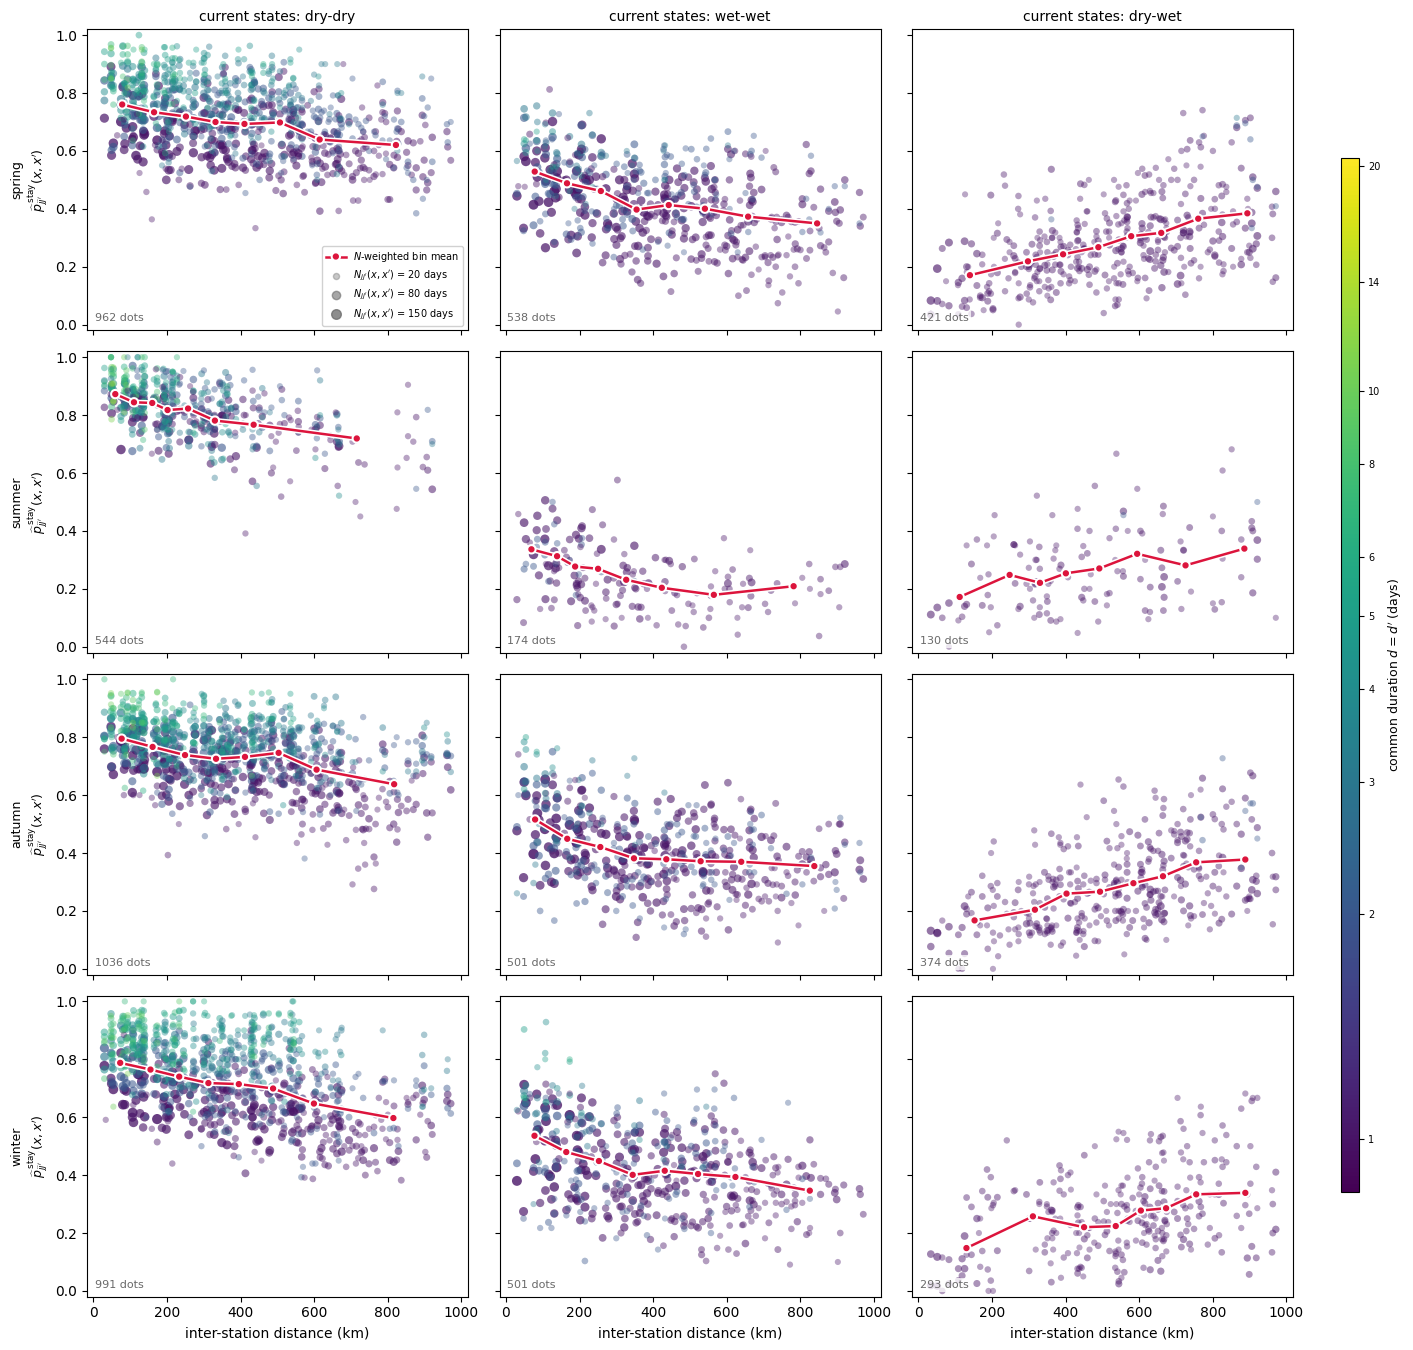

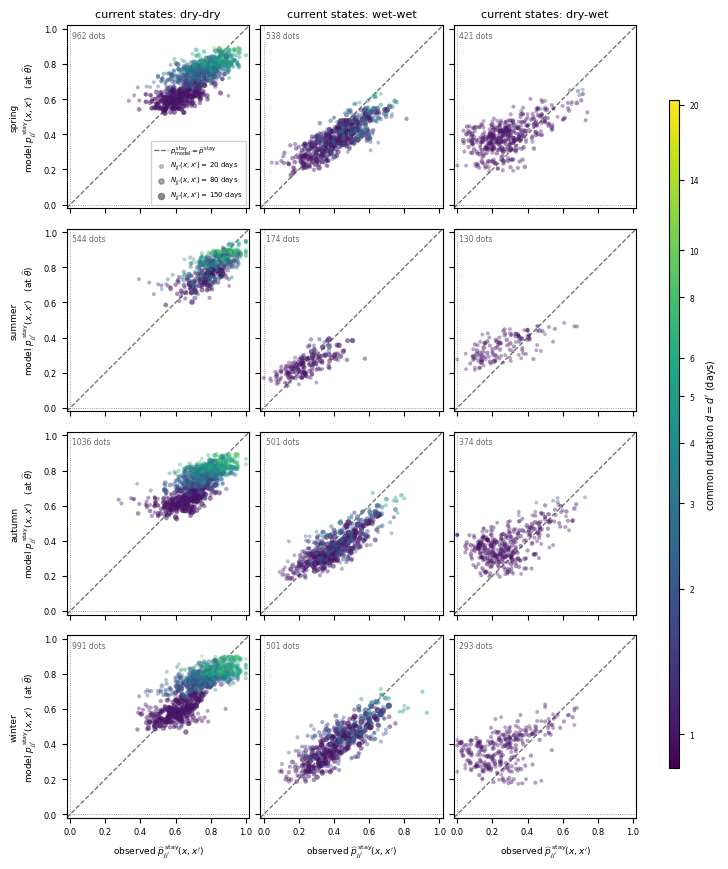

In [3]:
# Two figures on the equal-duration cells d = d': the observed frequency
# p^stay against inter-station distance, then the same cells read through the
# fitted model. theta_hat is loaded here -- the only fitted quantity of this
# section, reused by the all-pairs cell and by the Delta^stay cell below.
from spatial_bmcd.switch_phi_duration_diagnostic import (
    p00_model_equal_duration,
    plot_psi_model_vs_obs_grid,
    psi_model_vs_obs_summary,
)

P00_MIN_N = 20      # admissibility rule of every p^stay figure of this section
THETA_KEYS = ["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"]
theta_csv = OUTPUT_DIR / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"


def p00_cell_metrics(b_j: np.ndarray, b_k: np.ndarray) -> dict:
    """Joint persistence: share of the cell's days on which neither station exits."""
    no_exit = (b_j == 0) & (b_k == 0)
    return {"p00": no_exit.mean(), "n_no_exit": int(no_exit.sum())}


p00_by_season = {s: equal_duration_metric_table(day_record_by_season[s],
                                                p00_cell_metrics)
                 for s in SEASONS}

# --- observed p^stay vs distance: figure of section 3.5 of the article --------
plot_equal_duration_metric_grid(
    p00_by_season, value_col="p00",
    value_label=r"$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$",
    y_range=(-0.02, 1.02),
    min_n=P00_MIN_N, legend_ns=(20, 80, 150),
    filenames=figure_targets("diag_p00_equal_duration_seasons"),
);

# --- p^stay at theta_hat on the very cells of the figure above ----------------
if not theta_csv.exists():
    print(f"{theta_csv.name} not found -- run the fit notebook first; comparison skipped")
else:
    df_theta = pd.read_csv(theta_csv, index_col="season")
    # `fit_theta_by_season` of the fit notebook appends a row per season, so a
    # re-run can leave a season in the CSV twice (summer does, at the time of
    # writing) and `.loc[s, k]` then returns a Series instead of a float. Keep
    # the last row of each season -- what the fit notebook's own
    # `load_theta_by_season` ends up with, its dict build letting the last win.
    df_theta = df_theta[~df_theta.index.duplicated(keep="last")]
    theta_by_season = {s: tuple(df_theta.loc[s, k] for k in THETA_KEYS) for s in SEASONS}

    # `p00_by_season` already carries the cell keys (station_j, station_k,
    # r_j, r_k, d) the model side needs; q_j, q_k, rho and p00_model are added
    # in place, along with the independence baseline used by the next figure.
    p00_model_by_season = {
        s: p00_model_equal_duration(p00_by_season[s], params_by_season[s],
                                    theta_by_season[s])
        for s in SEASONS
    }
    # One shared dot-size reference, so every p^stay scatter is comparable.
    N_REF_P00 = float(max(t["n_days"].max() for t in p00_model_by_season.values()))

    fig_p00_model = plot_psi_model_vs_obs_grid(
        p00_model_by_season, obs_col="p00", model_col="p00_model",
        seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX, n_ref=N_REF_P00,
        legend_ns=(20, 80, 150), lims=(-0.02, 1.02),
        xlabel=r"observed $\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$",
        ylabel=r"model $p^{\,\mathrm{stay}}_{jj'}(x,x')$   (at $\widehat{\theta}$)",
        identity_label=r"$p^{\,\mathrm{stay}}_{\mathrm{model}} = \widehat{p}^{\,\mathrm{stay}}$",
        filenames=figure_targets("diag_p00_model_vs_obs_equal_duration"),
    )

    p00_summary = psi_model_vs_obs_summary(
        p00_model_by_season, obs_col="p00", model_col="p00_model",
        seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX,
    )
    p00_summary.to_csv(OUTPUT_DIR / "p00_model_vs_obs_equal_duration_summary.csv")
    print("\np^stay at theta_hat vs the observed frequency, N-weighted:")
    print(p00_summary.round(3).to_string())

### The same estimate off the diagonal -- all $(d, d')$ pairs


[spring]   4269 cells,  1921/1921 on the diagonal, max |p00 - p00 (equal-duration table)| = 0.00e+00
[summer]   1512 cells,   848/848 on the diagonal, max |p00 - p00 (equal-duration table)| = 0.00e+00
[autumn]   4042 cells,  1911/1911 on the diagonal, max |p00 - p00 (equal-duration table)| = 0.00e+00
[winter]   3426 cells,  1785/1785 on the diagonal, max |p00 - p00 (equal-duration table)| = 0.00e+00

p^stay at theta_hat vs the observed frequency, all (d, d'), N-weighted:
                n_dots  obs mean (N-w.)  model mean (N-w.)  bias (model - obs)   rmse  corr (N-w.)
season class                                                                                      
spring dry-dry    2019            0.701              0.702               0.001  0.079        0.701
       wet-wet    1023            0.430              0.394              -0.036  0.089        0.801
       dry-wet    1227            0.326              0.441               0.115  0.169        0.615
summer dry-dry     984       

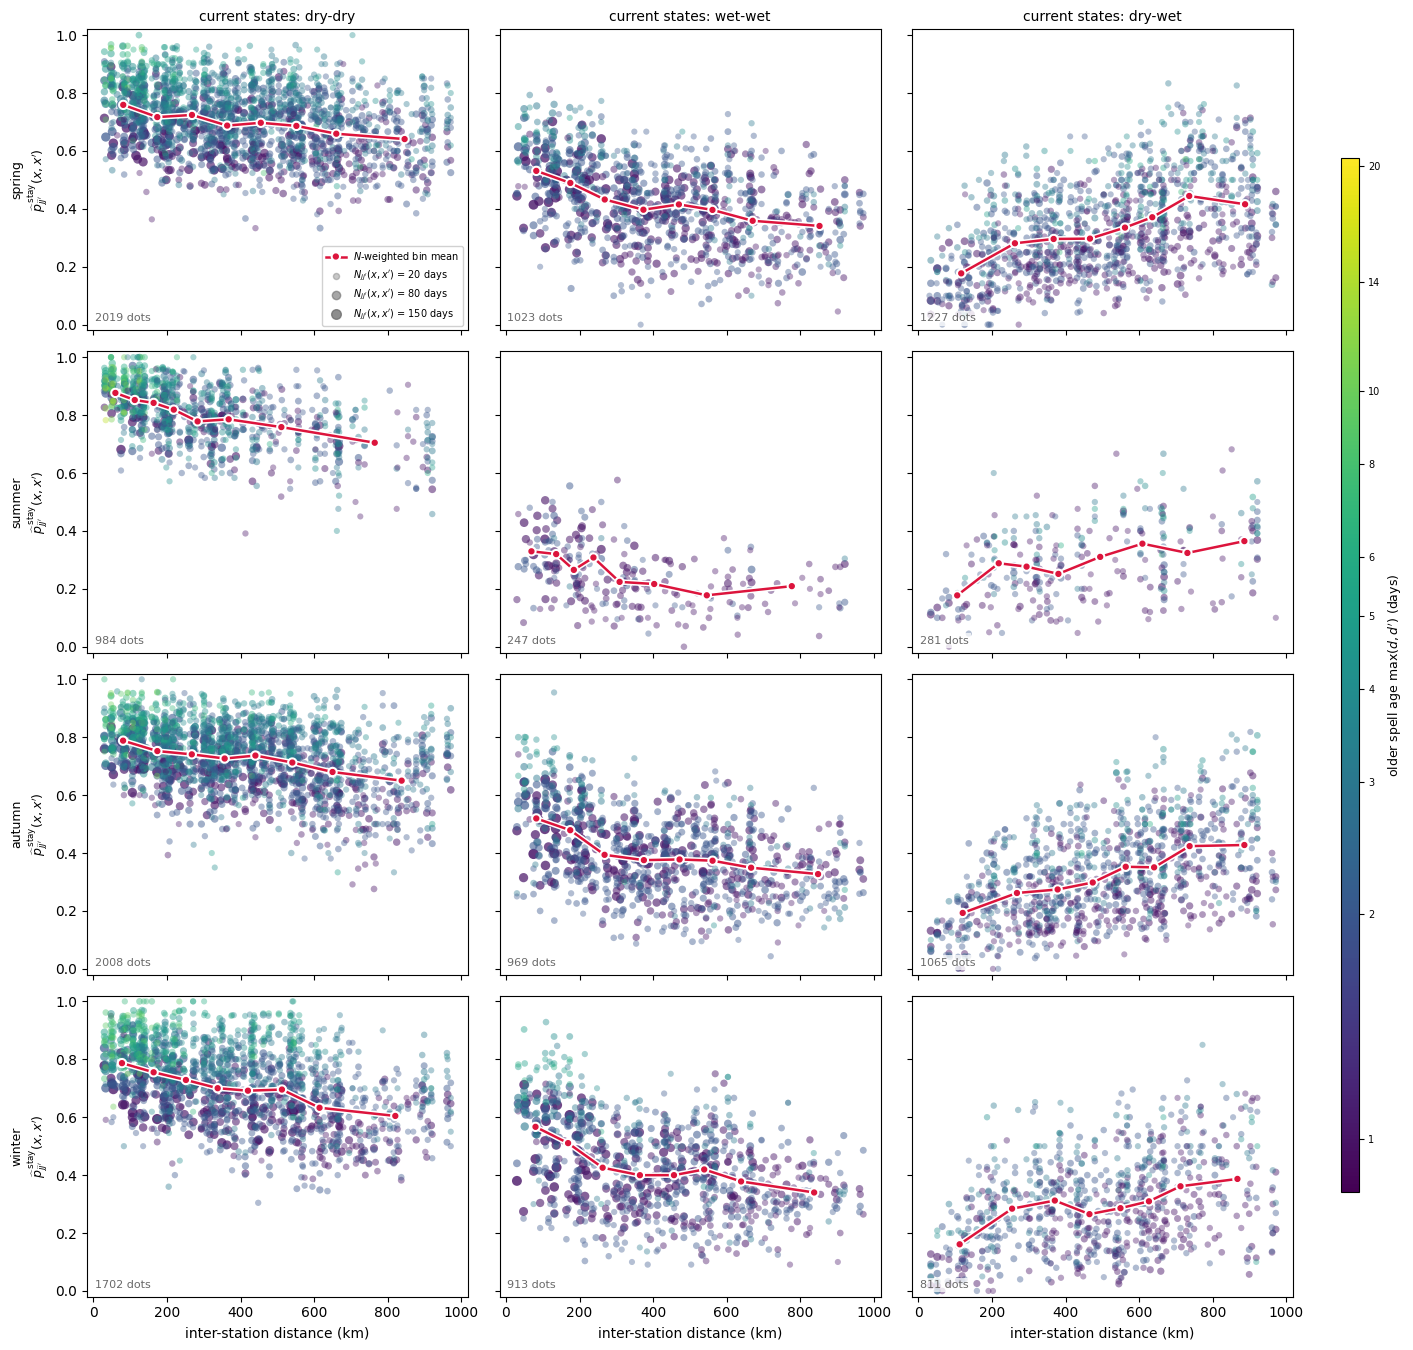

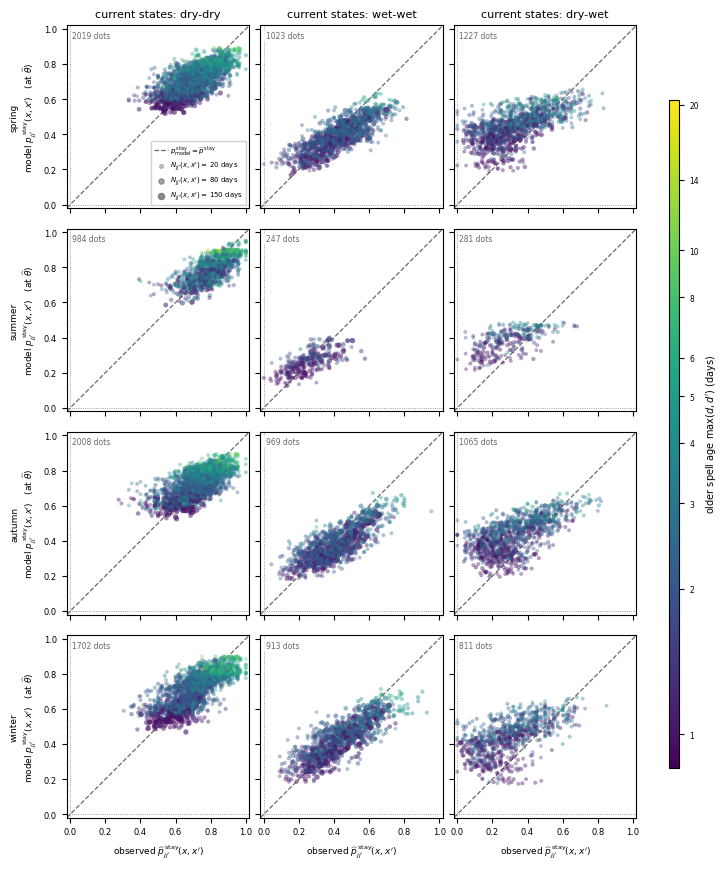

In [4]:
P00_MIN_N = 20      # admissibility rule of every p^stay figure of this section

# The two figures of the cell above with the constraint d = d' dropped: every
# pair of spell ages (d, d'), observed then at theta_hat.
def all_duration_metric_table(day_record, cell_metrics, d_max: int = D_MAX,
                              min_n: int = 1) -> pd.DataFrame:
    """One row per (station pair, r, r', d <= d_max, d' <= d_max): day count + metrics.

    Off-diagonal counterpart of `equal_duration_metric_table`: the two spell
    ages are no longer required to be equal, so a pair contributes up to
    4 x d_max^2 cells instead of 4 x d_max. The days of a pair are grouped by
    sorting one integer key per cell rather than by re-scanning the record once
    per cell, which the ~400x larger number of cells makes worth doing; `min_n`
    drops the cells below the admissibility rule as they are built, keeping the
    table to the rows a figure can use. `d` is max(d, d') -- what the colour of
    the figures carries -- so `plot_equal_duration_metric_grid` and
    `plot_psi_model_vs_obs_grid` read this table as they read the
    equal-duration one, while `d_j` and `d_k` give each station its own spell
    age, which is what the model side needs off the diagonal.
    """
    R, D, B = day_record["R"], day_record["D"], day_record["B"]
    names, dist = day_record["station_names"], day_record["dist"]
    valid = np.isfinite(R) & np.isfinite(D) & np.isfinite(B)
    rows = []
    for j in range(len(names) - 1):
        for k in range(j + 1, len(names)):
            ok = valid[:, j] & valid[:, k]           # both stations on days n, n+1
            d_j, d_k = D[ok, j].astype(int), D[ok, k].astype(int)
            keep = ((d_j >= 1) & (d_j <= d_max) & (d_k >= 1) & (d_k <= d_max))
            d_j, d_k = d_j[keep], d_k[keep]
            r_j, r_k = R[ok, j].astype(int)[keep], R[ok, k].astype(int)[keep]
            b_j, b_k = B[ok, j].astype(int)[keep], B[ok, k].astype(int)[keep]
            if d_j.size == 0:
                continue
            key = ((r_j * 2 + r_k) * (d_max + 1) + d_j) * (d_max + 1) + d_k
            srt = np.argsort(key, kind="stable")     # each cell a contiguous slice
            key, r_j, r_k = key[srt], r_j[srt], r_k[srt]
            d_j, d_k, b_j, b_k = d_j[srt], d_k[srt], b_j[srt], b_k[srt]
            starts = np.flatnonzero(np.r_[True, key[1:] != key[:-1]])
            for a, b in zip(starts, np.r_[starts[1:], key.size]):
                if b - a < min_n:
                    continue
                r, rp = int(r_j[a]), int(r_k[a])
                dd, ddp = int(d_j[a]), int(d_k[a])
                rows.append({
                    "station_j": names[j], "station_k": names[k],
                    "dist": float(dist[j, k]),
                    "state_class": ("dry-dry" if r == rp == 0 else
                                    "wet-wet" if r == rp == 1 else "dry-wet"),
                    "r_j": r, "r_k": rp,
                    "d_j": dd, "d_k": ddp,
                    "d": max(dd, ddp), "d_diff": abs(dd - ddp),
                    "n_days": int(b - a),
                    **cell_metrics(b_j[a:b], b_k[a:b]),
                })
    return pd.DataFrame(rows)


p00_all_dur_by_season = {
    s: all_duration_metric_table(day_record_by_season[s], p00_cell_metrics,
                                 min_n=P00_MIN_N)
    for s in SEASONS
}

# Sanity check: the d = d' rows must reproduce the table of the cell above.
for season in SEASONS:
    m = p00_all_dur_by_season[season].query("d_j == d_k").merge(
        p00_by_season[season][p00_by_season[season]["n_days"] >= P00_MIN_N],
        on=["station_j", "station_k", "r_j", "r_k", "d"], suffixes=("", "_eq"),
    )
    n_eq = int((p00_by_season[season]["n_days"] >= P00_MIN_N).sum())
    print(f"[{season:>6}] {len(p00_all_dur_by_season[season]):>6} cells, "
          f"{len(m):>5}/{n_eq} on the diagonal, "
          f"max |p00 - p00 (equal-duration table)| = "
          f"{np.abs(m['p00'] - m['p00_eq']).max():.2e}")

# --- observed p^stay vs distance, all (d, d') --------------------------------
plot_equal_duration_metric_grid(
    p00_all_dur_by_season, value_col="p00",
    value_label=r"$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$",
    y_range=(-0.02, 1.02),
    min_n=P00_MIN_N, legend_ns=(20, 80, 150),
    cbar_label=r"older spell age $\max(d, d')$ (days)",
    filenames=figure_targets("diag_p00_all_duration_seasons"),
);

# --- the same cells at theta_hat -------------------------------------------
# `p00_model_equal_duration` reads q_j at d and q_k at d' from the `d_j`/`d_k`
# columns, rho being selected by the state pair alone, so the model side is
# the same expression off the diagonal as on it.
if "theta_by_season" not in globals():
    print("no theta_by_season in the namespace -- run the cell above first")
else:
    p00_model_all_dur_by_season = {
        s: p00_model_equal_duration(p00_all_dur_by_season[s], params_by_season[s],
                                    theta_by_season[s])
        for s in SEASONS
    }

    fig_p00_model_all_dur = plot_psi_model_vs_obs_grid(
        p00_model_all_dur_by_season, obs_col="p00", model_col="p00_model",
        seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX, n_ref=N_REF_P00,
        legend_ns=(20, 80, 150), lims=(-0.02, 1.02),
        xlabel=r"observed $\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$",
        ylabel=r"model $p^{\,\mathrm{stay}}_{jj'}(x,x')$   (at $\widehat{\theta}$)",
        identity_label=r"$p^{\,\mathrm{stay}}_{\mathrm{model}} = \widehat{p}^{\,\mathrm{stay}}$",
        cbar_label=r"older spell age $\max(d, d')$ (days)",
        filenames=figure_targets("diag_p00_model_vs_obs_all_duration"),
    )

    p00_all_dur_summary = psi_model_vs_obs_summary(
        p00_model_all_dur_by_season, obs_col="p00", model_col="p00_model",
        seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX,
    )
    p00_all_dur_summary.to_csv(OUTPUT_DIR / "p00_model_vs_obs_all_duration_summary.csv")
    print("\np^stay at theta_hat vs the observed frequency, all (d, d'), N-weighted:")
    print(p00_all_dur_summary.round(3).to_string())

### Standardising $p^{\,\mathrm{stay}}$ — the correlation of the exit indicators recovered

Fix a cell, $x=(r,d)$, $x'=(r',d)$, and write $q_j = q^{(r)}_{\mathbf{s}_j}(d)$, $q_{j'} = q^{(r')}_{\mathbf{s}_{j'}}(d)$. Conditionally on the cell, the stay indicators $1-B_{n,j}$ and $1-B_{n,j'}$ are Bernoulli of parameters $1-q_j$ and $1-q_{j'}$, and $p^{\,\mathrm{stay}}$ is their joint success probability, so

$$\mathrm{Cov}\big(1-B_{n,j},\,1-B_{n,j'}\big) = p^{\,\mathrm{stay}}_{jj'}(x,x') - (1-q_j)(1-q_{j'}),
\qquad
\mathrm{Var}\big(1-B_{n,j}\big) = q_j(1-q_j).$$

Dividing the covariance by the two standard deviations gives the *standardised* co-persistence, the Pearson correlation of the two stay indicators:

$$\psi^{\mathrm{stay}}_{jj'}(x,x') = \frac{p^{\,\mathrm{stay}}_{jj'}(x,x') - (1-q_j)(1-q_{j'})}{\sqrt{q_j(1-q_j)\,q_{j'}(1-q_{j'})}}.$$

Flipping both indicators leaves a correlation unchanged, $\mathrm{Corr}(1-B_{n,j},\,1-B_{n,j'}) = \mathrm{Corr}(B_{n,j},\,B_{n,j'})$, so $\psi^{\mathrm{stay}}$ *is* the $\psi$ of eq. (12): substituting the model's $p^{\,\mathrm{stay}} = 1 - q_j - q_{j'} + \Phi_2\big(z_{\mathbf{s}_j}, z_{\mathbf{s}_{j'}};\, \rho^{(r,r')}_{jj'}\big)$ turns the numerator into $\Phi_2 - q_j q_{j'}$ and eq. (12) is recovered verbatim. The three readings of a cell differ by cell constants only:

$$p^{\,\mathrm{stay}}
\;\xrightarrow{\;-\,(1-q_j)(1-q_{j'})\;}\;
\Delta^{\mathrm{stay}} = \mathrm{Cov}\big(B_{n,j},B_{n,j'}\big)
\;\xrightarrow{\;/\sqrt{q_j(1-q_j)\,q_{j'}(1-q_{j'})}\;}\;
\psi = \mathrm{Corr}\big(B_{n,j},B_{n,j'}\big).$$

On the observed side the margins have to be plugged in, and there are two choices:

- the fitted $q$'s, as $\widehat{\Delta}^{\mathrm{stay}}$ does: $\widehat{\psi}^{\mathrm{stay}} = \widehat{\Delta}^{\mathrm{stay}} \big/ \sqrt{q_j(1-q_j)\,q_{j'}(1-q_{j'})}$ — defined on every cell, its noise that of $\widehat{p}^{\,\mathrm{stay}}$ divided by a constant, not confined to $[-1,1]$;
- the empirical exit rates $e_j/N$, $e_{j'}/N$ of the cell: this is eq. (9) — $\widehat{\psi} \in [-1,1]$, undefined when a margin is degenerate ($e \in \{0,N\}$).

The first keeps the $x$-axis a rescaled $\widehat{p}^{\,\mathrm{stay}}$, comparable with the two scatters above; in the `p00_model_by_season` tables it is `delta_p00 / sqrt(q_j (1 - q_j) q_k (1 - q_k))`, and the model side `delta_p00_model` divided by the same constant is the `psi_model` column already there.


### The equal-duration figure with the margins taken out — $\Delta^{\mathrm{stay}}_{jj'}(x,x')$

To make the scatter speak about the *spatial* layer rather than about the single-site fits, subtract from each side the value the same cell would take with the two exits drawn independently, $(1-q_j)(1-q_{j'})$:

$$\widehat{\Delta}^{\mathrm{stay}}_{jj'}(x,x') = \widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x') - \big(1-q^{(r)}_{\mathbf{s}_j}(d)\big)\big(1-q^{(r')}_{\mathbf{s}_{j'}}(d)\big),
\qquad
\Delta^{\mathrm{stay}}_{jj'}(x,x') = \Phi_2\big(z_{\mathbf{s}_j}, z_{\mathbf{s}_{j'}};\, \rho^{(r,r')}_{jj'}\big) - q^{(r)}_{\mathbf{s}_j}(d)\,q^{(r')}_{\mathbf{s}_{j'}}(d),$$

the model side collapsing to the plain covariance of the two exit indicators — exactly the numerator of eq. (12), i.e. $\widehat{\psi}$ *without* the $\sqrt{q(1-q)q'(1-q')}$ normalisation. Both $q$'s cancel out of the difference, so what is left on either axis is only the dependence, and the reference value is now $\Delta^{\mathrm{stay}} = 0$ (dotted lines) as well as the identity (dashed).

Compared with the $\widehat{\psi}$ scatter (eq. 9, archived at the end of the notebook) this keeps $p^{\,\mathrm{stay}}$'s two advantages — no $\pm 1$ saturation on the small cells, and it is defined on the cells with a degenerate exit margin, which eq. (9) has to drop — at the cost of a scale that varies with the margins from cell to cell ($|\Delta^{\mathrm{stay}}| \leq \sqrt{q_j(1-q_j)q_{j'}(1-q_{j'})}$, so cells with a rare exit are compressed towards 0 whatever their correlation). Read the two together: $\widehat{\psi}$ for the strength of the dependence, $\Delta^{\mathrm{stay}}$ for its contribution to the co-persistence actually observed.

The observed $\widehat{\Delta}^{\mathrm{stay}}$ uses the *fitted* $q$'s for its baseline, not per-cell empirical exit rates, so its sampling noise is that of $\widehat{p}^{\,\mathrm{stay}}$ alone — the $x$-axis stays a plug-in estimate over $N_{jj'}(x,x')$ days while the $y$-axis is deterministic, as in the two $p^{\,\mathrm{stay}}$ scatters above.



excess over independence, model at theta_hat vs observed, N-weighted:
                n_dots  obs mean (N-w.)  model mean (N-w.)  bias (model - obs)    rmse  corr (N-w.)
season class                                                                                       
spring dry-dry     962           0.0477             0.0489              0.0012  0.0728       0.3791
       wet-wet     538           0.1067             0.0618             -0.0449  0.0871       0.4591
       dry-wet     421          -0.1307            -0.0246              0.1061  0.1547       0.6406
summer dry-dry     544           0.0435             0.0288             -0.0148  0.0641       0.3488
       wet-wet     174           0.0747             0.0715             -0.0031  0.0738       0.5935
       dry-wet     130          -0.1019            -0.0158              0.0861  0.1320       0.4749
autumn dry-dry    1036           0.0530             0.0504             -0.0027  0.0682       0.4818
       wet-wet     501       

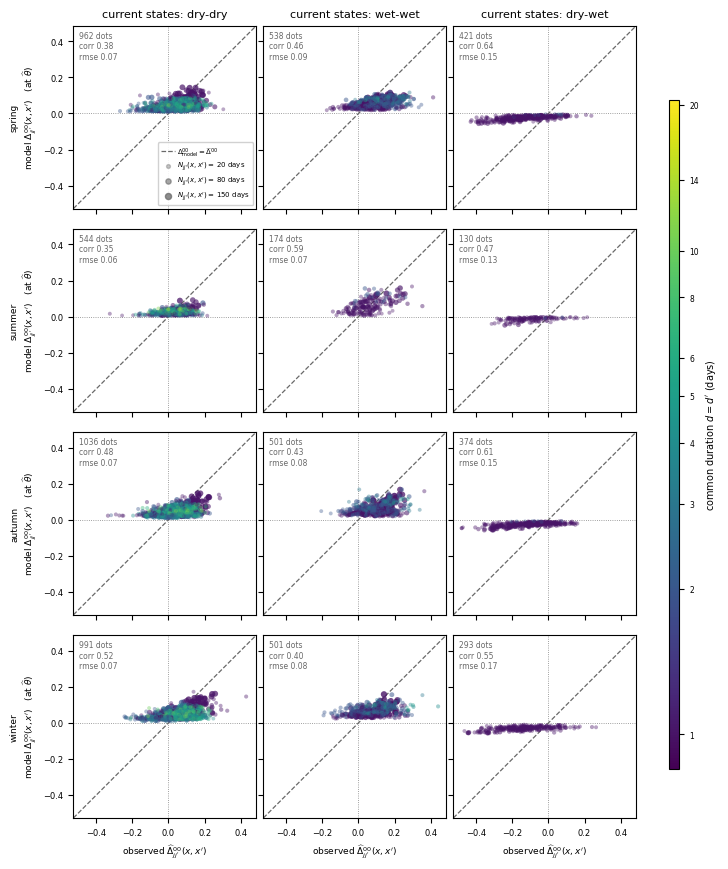

In [ ]:
# Same cells, same encoding, margins removed from both axes: what is left is
# the dependence alone, with 0 (no spatial structure) as the reference value.
if "p00_model_by_season" not in globals():
    print("no p00_model_by_season in the namespace -- run the previous cell first")
else:
    fig_delta_p00 = plot_psi_model_vs_obs_grid(
        p00_model_by_season, obs_col="delta_p00", model_col="delta_p00_model",
        seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX, n_ref=N_REF_P00,
        legend_ns=(20, 80, 150),
        xlabel=r"observed $\widehat{\Delta}^{\mathrm{stay}}_{jj'}(x,x')$",
        ylabel=r"model $\Delta^{\mathrm{stay}}_{jj'}(x,x')$   (at $\widehat{\theta}$)",
        identity_label=r"$\Delta^{\mathrm{stay}}_{\mathrm{model}} = \widehat{\Delta}^{\mathrm{stay}}$",
        filenames=figure_targets("diag_delta_p00_model_vs_obs_equal_duration"),
    )

    delta_summary = psi_model_vs_obs_summary(
        p00_model_by_season, obs_col="delta_p00", model_col="delta_p00_model",
        seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX,
    )
    delta_summary.to_csv(OUTPUT_DIR / "delta_p00_model_vs_obs_equal_duration_summary.csv")
    print("\nexcess over independence, model at theta_hat vs observed, N-weighted:")
    print(delta_summary.round(4).to_string())


# Archives

## Synchronicity of the spells: $\widehat{\gamma}_{jj'}(r,r')$

Let us define the sets:

$$\begin{equation*}\mathcal{N}_{jj'}(r,r')
=\big\{\,n \;:\; r_{n,j}=r,\ r_{n,j'}=r',\ \text{both stations observed on days } n \text{ and } n+1\,\big\},\qquad
N_{jj'}(r,r') := \big|\mathcal{N}_{jj'}(r,r')\big|.\end{equation*}$$

Then let us define

$$
\widehat \gamma_{jj'}(r,r') = \frac{1}{2{N}_{jj'}(r,r')} \sum_{n \in \mathcal{N}_{jj'}(r,r')} \big( d_{n,j} - d_{n,j'} \big)^2 ,
$$

Perfect synchronicity: $\gamma_{jj'}(r,r') = 0$


rows per season (pair x state pair): spring=1300, summer=1300, autumn=1300, winter=1300


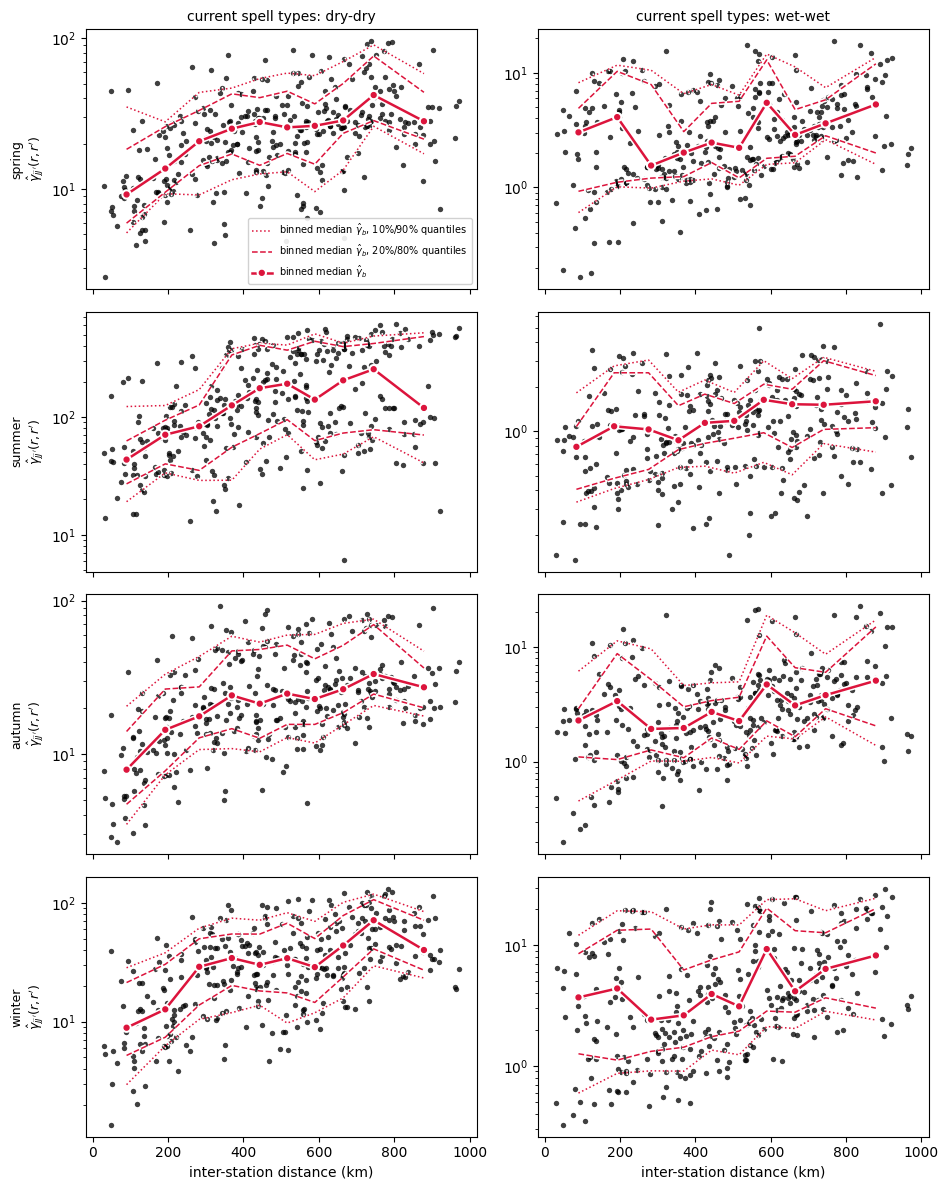

In [ ]:
def state_pair_metric_table(day_record, cell_metrics) -> pd.DataFrame:
    R, D, B = day_record["R"], day_record["D"], day_record["B"]
    names, dist = day_record["station_names"], day_record["dist"]
    valid = np.isfinite(R) & np.isfinite(D) & np.isfinite(B)
    rows = []
    for j in range(len(names) - 1):
        for k in range(j + 1, len(names)):
            ok = valid[:, j] & valid[:, k]        # both stations on days n, n+1
            r_j, r_k = R[ok, j].astype(int), R[ok, k].astype(int)
            d_j, d_k = D[ok, j].astype(int), D[ok, k].astype(int)
            b_j, b_k = B[ok, j].astype(int), B[ok, k].astype(int)
            for r, rp in ((0, 0), (1, 1), (0, 1), (1, 0)):
                sel = (r_j == r) & (r_k == rp)
                if not sel.any():
                    continue
                rows.append({
                    "station_j": names[j], "station_k": names[k],
                    "dist": float(dist[j, k]),
                    "state_class": ("dry-dry" if r == rp == 0 else
                                    "wet-wet" if r == rp == 1 else "dry-wet"),
                    "r_j": r, "r_k": rp,
                    "n_days": int(sel.sum()),
                    **cell_metrics(d_j[sel], d_k[sel], b_j[sel], b_k[sel]),})
    return pd.DataFrame(rows)


def plot_state_pair_metric_grid(
    table_by_season,value_col,value_label=None,state_classes=("dry-dry", "wet-wet", "dry-wet"),
    min_n=MIN_DAYS,seasons=SEASONS,extra_hover=(),text_col=None,n_ref=None,
    height: int = 1250,y_range=None,log_y: bool = False,color="#2b6cb0",title=None,):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    seasons, state_classes = list(seasons), list(state_classes)
    value_label = value_col if value_label is None else value_label
    frames, n_max = {}, 1.0     # one shared n_ref so dot sizes compare across panels
    for season in seasons:
        for cls in state_classes:
            df = table_by_season[season]
            df = df[(df["state_class"] == cls) & np.isfinite(df[value_col])]
            if len(df):
                n_max = max(n_max, float(df["n_days"].max()))
            if min_n is not None:
                df = df[df["n_days"] >= min_n]
            frames[season, cls] = df.sort_values("n_days", ascending=False)
    n_ref = n_max if n_ref is None else float(n_ref)

    if log_y:    # a perfectly synchronised pair sits at 0, which a log axis cannot show
        off = pd.concat([f[f[value_col] <= 0] for f in frames.values() if len(f)])
        if len(off):
            print(f"note: {len(off)} point(s) with {value_col} <= 0 left off the log "
                  "y-axis: " + ", ".join(
                      f"{r.station_j}-{r.station_k} ({r.state_class}, N={r.n_days})"
                      for r in off.itertuples()))

    hover_cols = ["station_j", "station_k", "n_days", *extra_hover]
    hover = (
        "<b>%{customdata[0]} &mdash; %{customdata[1]}</b><br>"
        "distance = %{x:.3f}<br>"
        f"<b>{value_col} = %{{y:.3f}}</b> &nbsp; N = %{{customdata[2]}} days"
        + "".join(f"<br>{c} = %{{customdata[{i}]}}"
                  for i, c in enumerate(extra_hover, start=3))
        + "<extra></extra>"
    )

    fig = make_subplots(rows=len(seasons), cols=len(state_classes),
                        column_titles=state_classes, row_titles=seasons,
                        shared_xaxes=True, shared_yaxes=True,
                        horizontal_spacing=0.02, vertical_spacing=0.02)
    for i, season in enumerate(seasons):
        for c, cls in enumerate(state_classes):
            df = frames[season, cls]
            # matplotlib's s is an area in pt^2, plotly's size a diameter in px.
            # N is carried by the dot area alone -- no opacity encoding.
            s_mpl, _ = _sqrtn_size_alpha(df["n_days"].to_numpy(), n_ref)
            fig.add_trace(
                go.Scattergl(
                    x=df["dist"], y=df[value_col],
                    mode="markers" if text_col is None else "markers+text",
                    text=None if text_col is None else df[text_col],
                    textposition="top center", textfont=dict(size=7),
                    customdata=df[hover_cols].to_numpy(dtype=object),
                    hovertemplate=hover, name=f"{season} {cls}", showlegend=False,
                    marker=dict(size=np.sqrt(s_mpl) * 2.2, opacity=0.9,
                                color=color, line=dict(width=0)),),
                row=i + 1, col=c + 1,)

    fig.update_xaxes(title_text="inter-station distance (normalised units)",
                     row=len(seasons))
    fig.update_yaxes(title_text=value_label, col=1, type="log" if log_y else "linear",
                     range=None if y_range is None else list(y_range))
    fig.update_layout(height=height, hovermode="closest",
                      margin=dict(l=80, r=40, t=110, b=60),
                      title=None if title is None else dict(text=title, x=0.5))
    return fig


def cell_metrics(d_j: np.ndarray, d_k: np.ndarray, b_j: np.ndarray, b_k: np.ndarray) -> dict:
    """Semi-variogram of the spell ages over N_{jj'}(r,r')."""
    x, y = d_j.astype(float), d_k.astype(float)
    gamma = 0.5 * float(np.mean((x - y) ** 2))
    return {"gamma": gamma,"rms_days": np.sqrt(2.0 * gamma),
        "mean_d_j": float(x.mean()), "mean_d_k": float(y.mean()),}


gamma_by_season = {s: state_pair_metric_table(day_record_by_season[s], cell_metrics)
                   for s in SEASONS}
print("rows per season (pair x state pair): " + ", ".join(
    f"{s}={len(gamma_by_season[s])}" for s in SEASONS))

GAMMA_HOVER = ("rms_days", "mean_d_j", "mean_d_k")

# Interactive version, kept to inspect individual pairs by hovering.
# plot_state_pair_metric_grid(
#     gamma_by_season, value_col="gamma",
#     value_label="gamma_hat  (days^2, eq. 7 ages)",
#     extra_hover=GAMMA_HOVER, log_y=True, title="",
# ).show()

# Article figure: matplotlib, concordant classes only, shared log y-axis.
from spatial_bmcd.switch_phi_duration_diagnostic import (
    plot_gamma_state_pair_season_grid,
)

_ = plot_gamma_state_pair_season_grid(
    gamma_by_season,
    state_classes=("dry-dry", "wet-wet"),
    min_n=MIN_DAYS,
    dot_size=15,
    dot_alpha=0.75,
    shared_y=False,   # each panel scaled to its own dots
    filenames=figure_targets("diag_gamma_synchronicity_seasons"),
    plot_quantiles = True,
    n_bins = 10,
    y_log = True
)

note: 1 estimate(s) with gamma_hat <= 0 left off the log colour scale


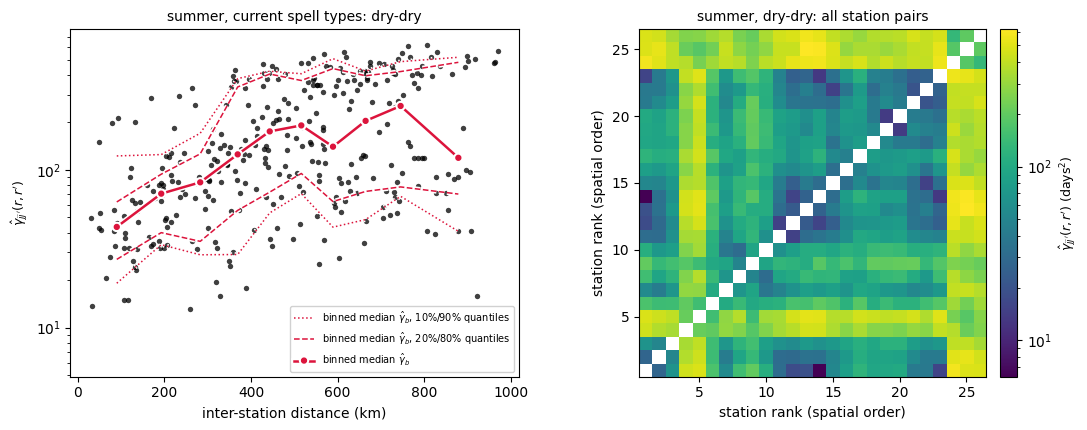

In [ ]:
# Article figure 1: the summer dry-dry estimates read twice on one row --
# against inter-station distance (left) and on the two station axes (right).
from spatial_bmcd.spatial_diagnostics import spatial_station_order
from spatial_bmcd.switch_phi_duration_diagnostic import (
    plot_gamma_distance_and_station_matrix,
)

stations = sorted(set.intersection(*(set(p) for p in params_by_season.values())))
order = spatial_station_order(
    {c: params_by_season["summer"][c] for c in stations}, stations,
)

_ = plot_gamma_distance_and_station_matrix(
    gamma_by_season["summer"],
    order,
    state_class="dry-dry",
    season="summer",
    min_n=MIN_DAYS,
    dot_size=15,
    dot_alpha=0.75,
    filenames=figure_targets("diag_gamma_synchronicity_dry_spells_summer"),
    plot_quantiles=True,
    n_bins=10,
    y_log=True,
)


### Plot with the graph with stations on x and y axis

note: 1 estimate(s) with gamma_hat <= 0 left off the log colour scale


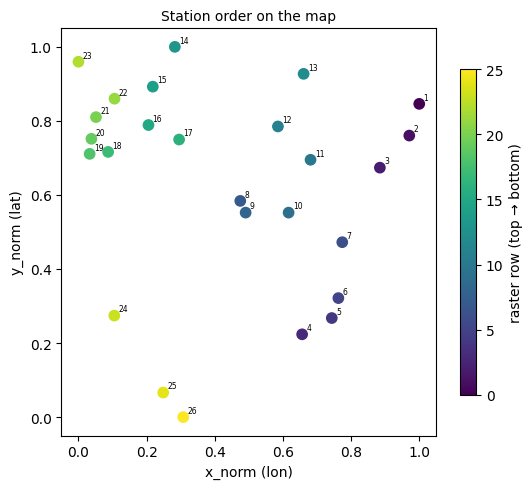

In [ ]:
from spatial_bmcd.spatial_diagnostics import plot_station_order_map, spatial_station_order
stations = sorted(set.intersection(*(set(p) for p in params_by_season.values())))
params_xy = {c: params_by_season["spring"][c] for c in stations}
order = spatial_station_order(params_xy, stations)
plot_station_order_map(params_xy, stations, order=order);


def gamma_station_pairs(table: pd.DataFrame, order, min_n=MIN_DAYS) -> pd.DataFrame:
    """One row per drawn dot: ranks on the two axes, gamma_hat > 0 (log colour)."""
    rank_of = {c: i + 1 for i, c in enumerate(order)}
    df = table[np.isfinite(table["gamma"]) & (table["gamma"] > 0)].copy()
    if min_n is not None:
        df = df[df["n_days"] >= min_n]
    df["rank_j"] = df["station_j"].map(rank_of)
    df["rank_k"] = df["station_k"].map(rank_of)
    if df[["rank_j", "rank_k"]].isna().any(axis=None):
        raise ValueError("station of the table absent from `order`")
    straight = df.rename(columns={"station_j": "station_x", "station_k": "station_y",
                                  "rank_j": "x", "rank_k": "y"})
    flipped = df.rename(columns={"station_k": "station_x", "station_j": "station_y",
                                 "rank_k": "x", "rank_j": "y"})
    dw = df["state_class"] == "dry-wet"   # only class whose two orientations differ
    return pd.concat([straight[~dw | (df["r_j"] == 0)],
                      flipped[~dw | (df["r_j"] == 1)]], ignore_index=True)


def plot_gamma_station_matrix(
    table_by_season, order, seasons=SEASONS,
    state_classes=("dry-dry", "wet-wet", "dry-wet"),
    min_n=MIN_DAYS, cmap="Viridis", marker_size=9, height=1400, title=None,
):
    """Season x class grid of station-by-station maps, dot colour = log10 gamma_hat."""
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    seasons, state_classes = list(seasons), list(state_classes)
    n_st = len(order)
    frames = {}
    for season in seasons:
        pairs = gamma_station_pairs(table_by_season[season], order, min_n=min_n)
        for cls in state_classes:
            frames[season, cls] = pairs[pairs["state_class"] == cls]
    dropped = sum(int((~(table_by_season[s]["gamma"] > 0)).sum()) for s in seasons)
    if dropped:   # a perfectly synchronised pair sits at 0, which a log scale cannot show
        print(f"note: {dropped} estimate(s) with gamma_hat <= 0 left off the log colour scale")

    g = np.concatenate([f["gamma"].to_numpy(float) for f in frames.values() if len(f)])
    cmin, cmax = float(np.log10(g.min())), float(np.log10(g.max()))
    ticks = [t for t in (0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000)
             if cmin <= np.log10(t) <= cmax]

    hover_cols = ["station_x", "station_y", "gamma", "rms_days", "dist", "n_days"]
    hover = (
        "<b>%{customdata[0]} (#%{x}) &mdash; %{customdata[1]} (#%{y})</b><br>"
        "<b>gamma_hat = %{customdata[2]:.2f} days^2</b> &nbsp; "
        "rms = %{customdata[3]:.2f} days<br>"
        "distance = %{customdata[4]:.3f} &nbsp; N = %{customdata[5]} days"
        "<extra></extra>"
    )

    fig = make_subplots(rows=len(seasons), cols=len(state_classes),
                        column_titles=state_classes, row_titles=seasons,
                        shared_xaxes=True, shared_yaxes=True,
                        horizontal_spacing=0.03, vertical_spacing=0.03)
    for i, season in enumerate(seasons):
        for c, cls in enumerate(state_classes):
            df = frames[season, cls]
            first = (i == 0 and c == 0)
            fig.add_trace(
                go.Scattergl(
                    x=df["x"], y=df["y"], mode="markers",
                    customdata=df[hover_cols].to_numpy(dtype=object),
                    hovertemplate=hover, name=f"{season} {cls}", showlegend=False,
                    marker=dict(
                        size=marker_size, symbol="square", line=dict(width=0),
                        color=np.log10(df["gamma"].to_numpy(float)),
                        colorscale=cmap, cmin=cmin, cmax=cmax,
                        colorbar=dict(
                            title=dict(text="gamma_hat (days^2)", side="right"),
                            tickvals=np.log10(ticks),
                            ticktext=[f"{t:g}" for t in ticks],
                            len=0.9, thickness=14,
                        ) if first else None,
                        showscale=first,
                    ),
                ),
                row=i + 1, col=c + 1,
            )

    fig.update_xaxes(range=[0.5, n_st + 0.5], dtick=5, showgrid=True,
                     title_text="station rank (spatial order)", row=len(seasons))
    fig.update_yaxes(range=[0.5, n_st + 0.5], dtick=5, showgrid=True,
                     title_text="station rank (spatial order)", col=1)
    fig.update_layout(height=height, hovermode="closest",
                      margin=dict(l=80, r=110, t=110, b=60),
                      title=None if title is None else dict(text=title, x=0.5))
    return fig


plot_gamma_station_matrix(
    gamma_by_season, order,
    title="gamma_hat over all station pairs -- axes: stations in spatial order "
          "(dry-wet panel: dry station on x, wet one on y)",
).show()

## Pearson correlation $\widehat{\psi}_{jj'}(x,x')$ eq. (9) : all pairs

Conditional Pearson correlation of the exit indicators over the $N_{jj'}(x,x')$ days on which the pair carries the state pair $(x, x')$,

$$\widehat{\psi}_{jj'}(x,x') = \frac{N_{jj'}(x,x')\,e_{jj'}-e_j\,e_{j'}}{\sqrt{e_j\big(N_{jj'}(x,x')-e_j\big)\;e_{j'}\big(N_{jj'}(x,x')-e_{j'}\big)}},$$

with $e_j, e_{j'}$ the exit counts and $e_{jj'}$ the joint exit count. Conditioning on the exact durations freezes the two exit probabilities, so the independence baseline is exactly $0$.

First, Figure 1 of the article — **all** state pairs at $N_{jj'}(x,x') \geq 10$, code reused as is: the per-season cell table cached in `experiment_outputs/switch_phi_duration_cells_<season>.csv` (recomputed from the raw ECAD record when a CSV is missing) and `plot_phi_per_cell_season_grid`.

In [ ]:
missing = [s for s in SEASONS
           if not (OUTPUT_DIR / f"switch_phi_duration_cells_{s}.csv").exists()]
if missing:
    print("no cache for " + ", ".join(missing) + " -- recomputing from the raw record...")
    recomputed = compute_cells_from_raw(
        params_by_season, seasons=missing, year_min=YEAR_MIN, year_max=YEAR_MAX,
        min_days_per_cell=MIN_DAYS,
    )
    for season, cells in recomputed.items():
        cells.to_csv(OUTPUT_DIR / f"switch_phi_duration_cells_{season}.csv", index=False)

cells_by_season = {s: pd.read_csv(OUTPUT_DIR / f"switch_phi_duration_cells_{s}.csv")
                   for s in SEASONS}

plot_phi_per_cell_season_grid(
    cells_by_season, seasons=SEASONS, legend_ns=(10, 80, 150),
    filenames=figure_targets("diag_switch_phi_duration_per_cell_seasons"),
);

## only pairs with $d = d' \leq 20$

$\widehat{\psi}$ below and the $\widehat{p}^{\,\mathrm{stay}}$ of the section above share one computation path on the day-level record $(R, D, B)$, both helpers being defined in the setup cell: `equal_duration_metric_table` builds one row per (station pair, $r$, $r'$, common duration $d = d' \leq 20$) holding the day count $N_{jj'}(x,x')$ and whatever a `cell_metrics(b_j, b_k)` function returns from the exit indicators of the cell — change the metric there. `plot_equal_duration_metric_grid` draws any such table on the shared season × class layout, in matplotlib and with the styling of the other article figures, dot area and opacity carrying $\sqrt{N}$ and the colour the common duration.

[spring]  3731 days x 26 stations
[summer]  3731 days x 26 stations
[autumn]  3690 days x 26 stations
[winter]  3660 days x 26 stations


### Pearson correlation $\widehat{\psi}$ on the diagonal

Eq. (9) again, one estimate per (station pair, state pair, common duration). Cells with a degenerate margin ($e \in \{0, N\}$) have a vanishing denominator and give `NaN`; the dotted line is the independence baseline $\psi = 0$.

[spring]  2926 shared cells, max |psi - cached phi| = 1.11e-16
[summer]  1419 shared cells, max |psi - cached phi| = 9.71e-17
[autumn]  2956 shared cells, max |psi - cached phi| = 1.11e-16
[winter]  2758 shared cells, max |psi - cached phi| = 1.11e-16


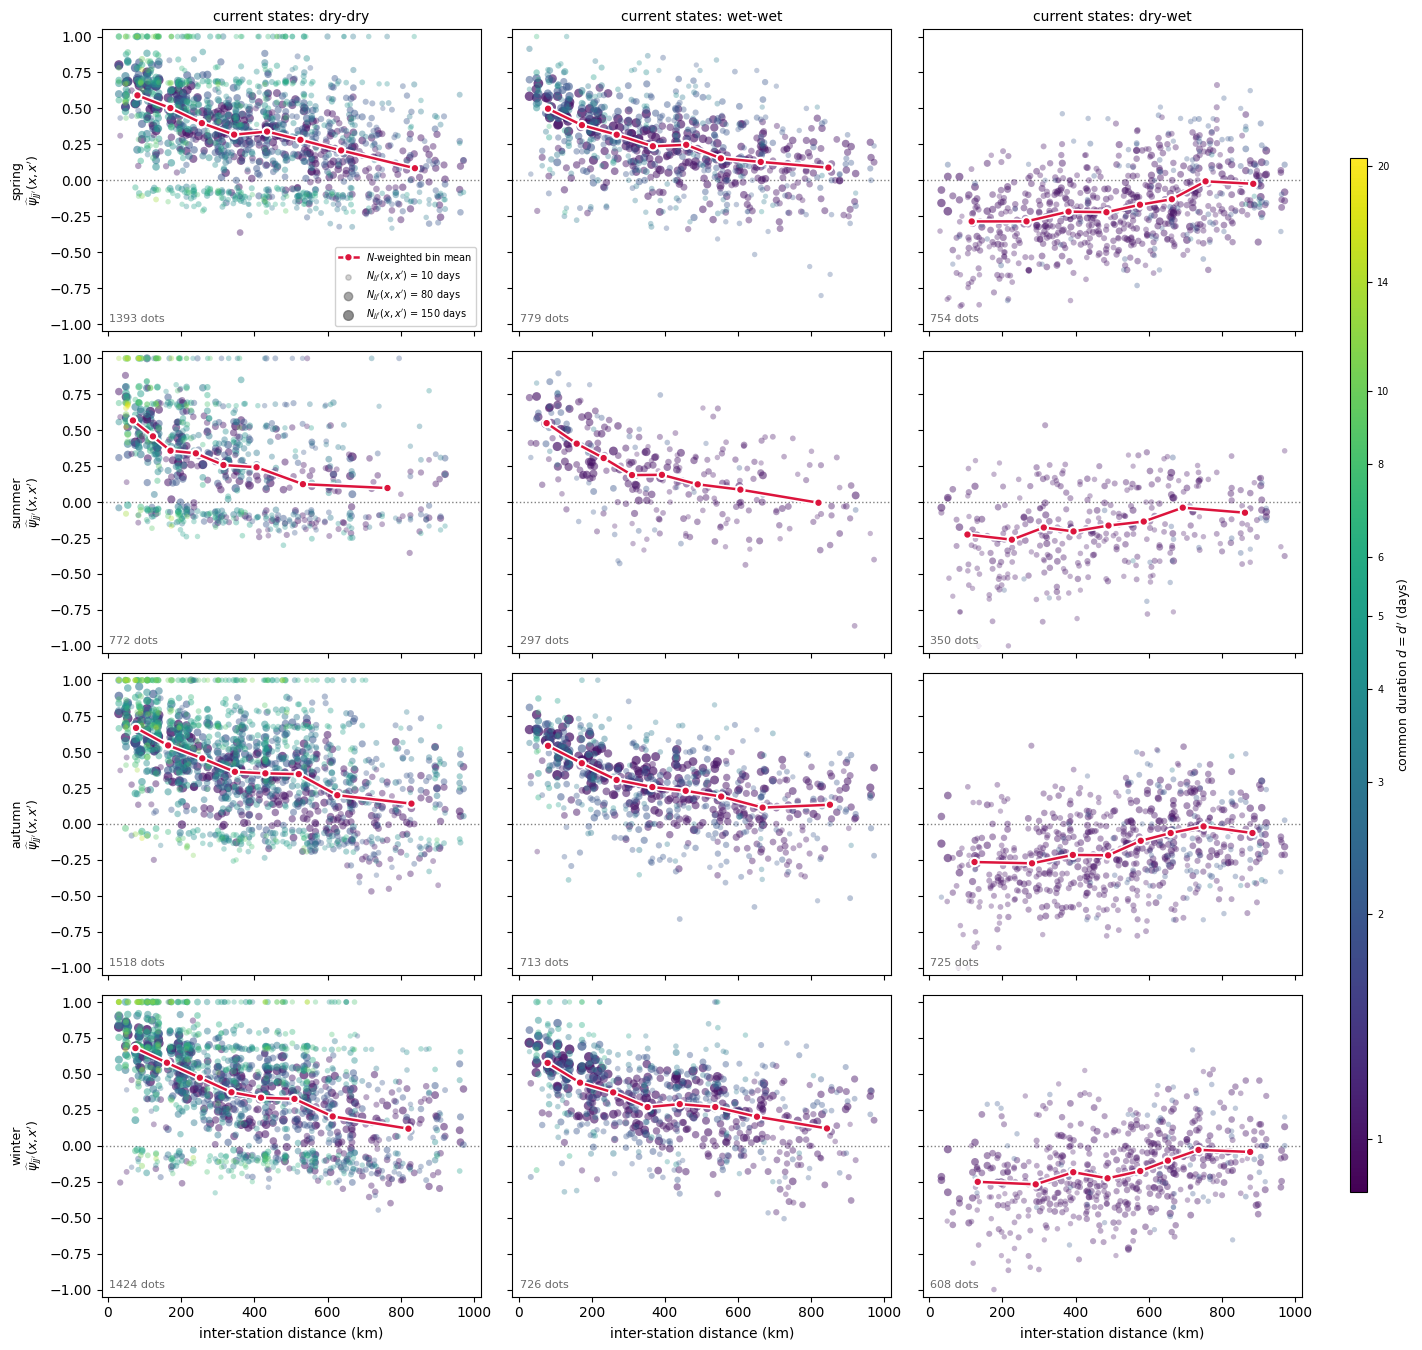

In [ ]:
def cell_metrics(b_j: np.ndarray, b_k: np.ndarray) -> dict:
    """Eq. (9): Pearson correlation of the two exit indicators of the cell."""
    n = b_j.size
    e_j, e_k, e_jk = int(b_j.sum()), int(b_k.sum()), int((b_j & b_k).sum())
    denom = e_j * (n - e_j) * e_k * (n - e_k)
    return {
        "psi": (n * e_jk - e_j * e_k) / np.sqrt(denom) if denom > 0 else np.nan,
        "e_j": e_j, "e_k": e_k, "e_jk": e_jk,
    }


psi_by_season = {s: equal_duration_metric_table(day_record_by_season[s], cell_metrics)
                 for s in SEASONS}

# Cross-check against the cached table of Figure 1 on the cells both estimators define.
for season in SEASONS:
    m = cells_by_season[season].query("d_j == d_k").merge(
        psi_by_season[season],
        left_on=["station_j", "station_k", "r_j", "r_k", "d_j"],
        right_on=["station_j", "station_k", "r_j", "r_k", "d"],
    )
    both = m[np.isfinite(m["phi"]) & np.isfinite(m["psi"])]
    print(f"[{season:>6}] {len(both):>5} shared cells, "
          f"max |psi - cached phi| = {np.abs(both['psi'] - both['phi']).max():.2e}")

plot_equal_duration_metric_grid(
    psi_by_season, value_col="psi",
    value_label=r"$\widehat{\psi}_{jj'}(x,x')$",
    y_range=(-1.05, 1.05), zero_line=True,
    min_n=10, legend_ns=(10, 80, 150),
);

## The same cells through the fitted model — eq. (12) against eq. (9)

The two $\widehat{\psi}$ figures above are model-free: eq. (9) reads $\widehat{\psi}_{jj'}(x,x')$ off the counts of the cell alone. The fitted model gives a *value* for that very same cell, eq. (12) of the article,

$$\psi_{jj'}(x,x') = \frac{\Phi_2\big(z_{\mathbf{s}_j}(r,d),\,z_{\mathbf{s}_{j'}}(r',d);\,\rho^{(r,r')}_{jj'}\big) - q^{(r)}_{\mathbf{s}_j}(d)\,q^{(r')}_{\mathbf{s}_{j'}}(d)}{\sqrt{q^{(r)}_{\mathbf{s}_j}(d)\big(1-q^{(r)}_{\mathbf{s}_j}(d)\big)\;q^{(r')}_{\mathbf{s}_{j'}}(d)\big(1-q^{(r')}_{\mathbf{s}_{j'}}(d)\big)}},$$

evaluated on the diagonal $d = d'$, so the two durations of the cell are the same one. The single-site exit probabilities $q^{(r)}_{\mathbf{s}_j}(d)$ come from the `params_by_season` dictionaries of the setup cell, their Gaussian thresholds $z = \Phi^{-1}(q)$ from eq. (10), and $\rho^{(r,r')}_{jj'}$ is the LMC block of eq. (15) — `C00`, `C11` or `C01` according to the state pair — at the $\widehat{\theta}$ fitted in [spatial_lin_mod_coregion_fit_spain_portugal.ipynb](spatial_lin_mod_coregion_fit_spain_portugal.ipynb) (state-dependent $\lambda$), read from the same `theta_fit_spain_portugal_by_season_state_dep_lambda.csv` as [switch_dependence_diagnostics.ipynb](switch_dependence_diagnostics.ipynb). $\Phi_2$ is the fast approximation of Appendix A, the one the pairwise likelihood itself uses. Both quantities are therefore one number per cell, and go on the two axes of a single scatter: $x = \widehat{\psi}$ of eq. (9), $y = \psi$ of eq. (12).

The slice of the state pairs, the grid and the dot encoding are those of the figure above — the equal-duration diagonal $d = d' \leq 20$ at $N_{jj'}(x,x') \geq 10$, one row per season, one column per state-pair class, the colour carrying $d = d'$ on the same log scale, the dot area **and** opacity carrying $N_{jj'}(x,x')$ through the same $\sqrt{N}$ mapping and the same $N = 10, 80, 150$ legend. What changes is that the inter-station distance leaves the $x$-axis to the observed estimate, and the reference is no longer the independence baseline but the identity $\psi_{\mathrm{model}} = \widehat{\psi}$ (grey dashed). All twelve panels share one square window, so a departure from that line reads the same everywhere; `lims=` zooms it, since the observed side saturates at $\pm 1$ while the model side stays inside $[-0.3, 0.9]$.

**How much the scatter can be asked to say.** Eq. (12) is deterministic given the cell, whereas eq. (9) is a plug-in estimate over $N_{jj'}(x,x')$ days: the two axes do not carry the same noise, and the horizontal spread is dominated by the sampling error of the observed side, which at $N \approx 10$ is large. The vertical stripes at $\widehat{\psi} = \pm 1$ and the band of the $e_{jj'} = 0$ locus (`plot_zero_joint_exit_diagnostic`) are that noise, not a model departure. The cloud is therefore not expected to hug the identity line, and the $N$-weighted correlation and RMSE printed in each panel and tabulated by `psi_model_vs_obs_summary` are descriptive, not a goodness-of-fit test — the noise-matched reading is the next figure, which repeats this one with the observed record replaced by one the fitted model generated.

Written to `figures/diag_switch_psi_model_vs_obs_equal_duration_min10.pdf` of the article directory (plus a `.png` copy and one in `figures/spatial/`).

[spring] theta_hat: lam0=0.847, lam1=0.199, sigma_wc=0.743, sigma_w0=0.015, sigma_w1=0.273
[summer] theta_hat: lam0=0.873, lam1=0.245, sigma_wc=0.440, sigma_w0=0.013, sigma_w1=0.240
[autumn] theta_hat: lam0=0.821, lam1=0.207, sigma_wc=0.861, sigma_w0=0.150, sigma_w1=0.290
[winter] theta_hat: lam0=0.349, lam1=0.476, sigma_wc=1.082, sigma_w0=0.509, sigma_w1=0.167

eq. (12) at theta_hat vs eq. (9) on the same cells, N-weighted:
                n_dots  obs mean (N-w.)  model mean (N-w.)  bias (model - obs)   rmse  corr (N-w.)
season class                                                                                      
spring dry-dry    1844            0.374              0.313              -0.061  0.248        0.555
       wet-wet    1094            0.290              0.256              -0.034  0.193        0.614
       dry-wet    1023           -0.147             -0.116               0.030  0.239        0.333
summer dry-dry    1006            0.353              0.265              -0.0

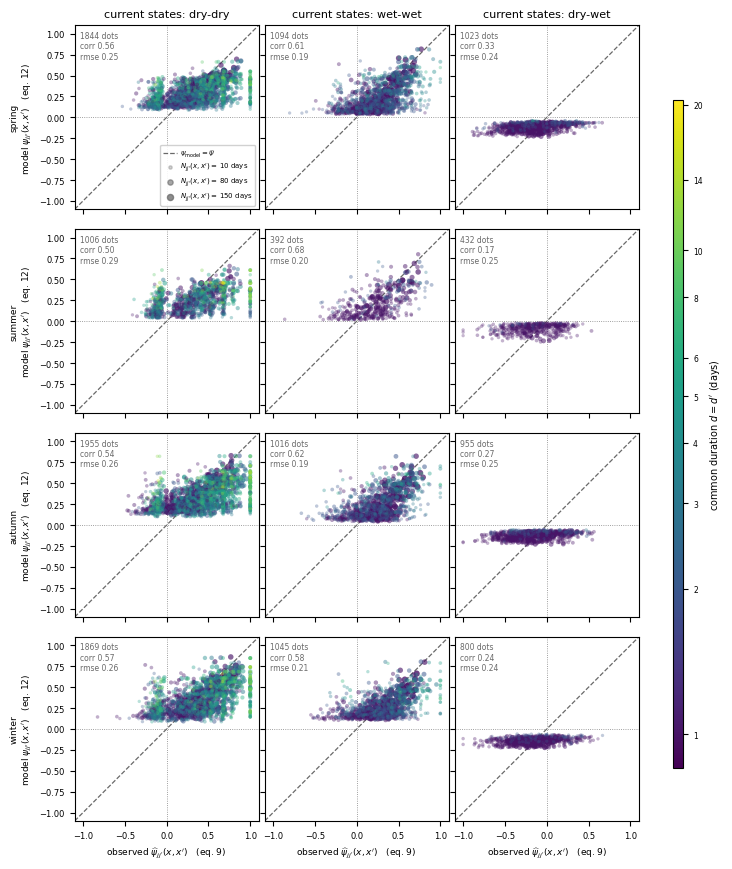

In [ ]:
# Equal-duration diagonal of the cached table -- the article's estimator, plus the
# dot-size reference shared by the matplotlib grids below.
diag_by_season = {s: equal_duration_estimates(c, d_max=D_MAX)
                  for s, c in cells_by_season.items()}
N_REF = float(max(diag["n_days"].max() for diag in diag_by_season.values()))

# Only cell of the notebook that uses a fitted quantity: theta_hat and the LMC blocks.
from spatial_bmcd.switch_phi_duration_diagnostic import (
    plot_psi_model_vs_obs_grid,
    psi_model_equal_duration,
    psi_model_vs_obs_summary,
)

THETA_KEYS = ["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"]
theta_csv = OUTPUT_DIR / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"

if not theta_csv.exists():
    print(f"{theta_csv.name} not found -- run the fit notebook first; comparison skipped")
else:
    df_theta = pd.read_csv(theta_csv, index_col="season")
    # `fit_theta_by_season` of the fit notebook appends a row per season, so a
    # re-run can leave a season in the CSV twice (summer does, at the time of
    # writing) and `.loc[s, k]` then returns a Series instead of a float. Keep
    # the last row of each season -- what the fit notebook's own
    # `load_theta_by_season` ends up with, its dict build letting the last win.
    df_theta = df_theta[~df_theta.index.duplicated(keep="last")]
    theta_by_season, diag_model_by_season = {}, {}
    for season in SEASONS:
        theta = tuple(df_theta.loc[season, k] for k in THETA_KEYS)
        theta_by_season[season] = theta
        diag_model_by_season[season] = psi_model_equal_duration(
            diag_by_season[season], params_by_season[season], theta,
        )
        print(f"[{season:>6}] theta_hat: "
              + ", ".join(f"{k}={v:.3f}" for k, v in zip(THETA_KEYS, theta)))

    fig_model_vs_obs = plot_psi_model_vs_obs_grid(
        diag_model_by_season, seasons=SEASONS, min_n=MIN_DAYS, d_max=D_MAX, n_ref=N_REF,
        filenames=figure_targets("diag_switch_psi_model_vs_obs_equal_duration_min10"),
    )

    cmp_summary = psi_model_vs_obs_summary(
        diag_model_by_season, seasons=SEASONS, min_n=MIN_DAYS, d_max=D_MAX,
    )
    cmp_summary.to_csv(OUTPUT_DIR / "switch_psi_model_vs_obs_equal_duration_summary.csv")
    print("\neq. (12) at theta_hat vs eq. (9) on the same cells, N-weighted:")
    print(cmp_summary.round(3).to_string())

## The same figure under a true model — $\widehat{\psi}$ on simulated data

The scatter above puts a deterministic value (eq. 12) against a plug-in estimate (eq. 9), so part of its spread is estimation noise rather than model departure. This cell measures that part, by replacing the record with one the fitted model *did* generate and leaving everything else untouched.

`simulated_psi_equal_duration` runs the three steps of the simulated cloud of [switch_dependence_diagnostics.ipynb](switch_dependence_diagnostics.ipynb) — `simulate_phi_cells` draws `N_REP` trajectories at $\widehat{\theta}$ with the algorithm of §"Simulation from a fitted model", blanks the days the corresponding station does not record (the observed NaN pattern of `Rbin`) and rebuilds $(R, D, S)$ with the same masking as the likelihood, then pushes the result through the *same* `switch_phi_duration_cells` — and takes the diagonal $d = d'$ of the outcome, with its model value from eq. (12) at that same $\widehat{\theta}$. The raw ECAD record is loaded here, the only cell of the notebook that needs it, for the dates and the missing-data pattern; it is kept in the namespace so re-running the cell does not reload it.

The $y$-axis, the grid, the colour and the dot encoding are exactly those of the figure above. What changes is the $x$-axis: eq. (9) read on data the model generated, so **every departure from the identity line is estimation noise**. The cells are redrawn by the simulation — a simulated cell carries its own $N_{jj'}(x,x')$, close to but not equal to the observed one for that state pair — which is why the dot counts differ slightly; `N_REP = 1` keeps them, and the distribution of $N$, comparable to the observed panel, raise it for a smoother cloud at the cost of that comparability.

Read one figure against the other: the panel-by-panel correlation and RMSE below are the values the panel above would show **if the model were exactly right**. Whatever the observed scatter shows on top of them is what is left for a genuine model departure.

Written to `figures/diag_switch_psi_model_vs_sim_equal_duration_min10.pdf` of the article directory (plus a `.png` copy and one in `figures/spatial/`).

In [ ]:
from spatial_bmcd.switch_phi_duration_diagnostic import (
    load_Rbin_by_season,
    simulated_psi_equal_duration,
)

N_REP, SEED0 = 1, 100

if "theta_by_season" not in globals():
    print("no theta_hat in the namespace -- run the previous cell first; simulation skipped")
else:
    # Raw ECAD record: dates and missing-data pattern the replicates reuse.
    # Slow step (~15 s), so it is kept across re-runs of the cell.
    if "Rbin_by_season" not in globals():
        Rbin_by_season = load_Rbin_by_season(
            params_by_season, seasons=SEASONS, year_min=YEAR_MIN, year_max=YEAR_MAX,
        )
    print("Rbin (days x stations): " + ", ".join(
        f"{s}={Rbin_by_season[s].shape}" for s in SEASONS))

    diag_sim_by_season = {}
    for season in SEASONS:
        diag_sim_by_season[season] = simulated_psi_equal_duration(
            theta_by_season[season], params_by_season[season], Rbin_by_season[season],
            d_max=D_MAX, n_rep=N_REP, seed0=SEED0,
        )
        n_sim = int((diag_sim_by_season[season]["n_days"] >= MIN_DAYS).sum())
        n_obs = int((diag_by_season[season]["n_days"] >= MIN_DAYS).sum())
        print(f"[{season:>6}] {n_sim} simulated estimates with N >= {MIN_DAYS} "
              f"(observed: {n_obs})")

    fig_model_vs_sim = plot_psi_model_vs_obs_grid(
        diag_sim_by_season, seasons=SEASONS, min_n=MIN_DAYS, d_max=D_MAX, n_ref=N_REF,
        xlabel=r"simulated $\widehat{\psi}_{jj'}(x,x')$   (eq. 9 at $\widehat{\theta}$)",
        filenames=figure_targets("diag_switch_psi_model_vs_sim_equal_duration_min10"),
    )

    sim_summary = psi_model_vs_obs_summary(
        diag_sim_by_season, seasons=SEASONS, min_n=MIN_DAYS, d_max=D_MAX,
    )
    sim_summary.to_csv(OUTPUT_DIR / "switch_psi_model_vs_sim_equal_duration_summary.csv")
    print("\neq. (12) vs eq. (9) on simulated data -- pure estimation noise, N-weighted:")
    print(sim_summary.round(3).to_string())

Rbin (days x stations): spring=(3772, 35), summer=(3772, 35), autumn=(3731, 35), winter=(3701, 35)
[spring] 3239 simulated estimates with N >= 10 (observed: 3961)
[summer] 1661 simulated estimates with N >= 10 (observed: 1830)
[autumn] 3481 simulated estimates with N >= 10 (observed: 3926)


KeyboardInterrupt: 